# ENVIRONMENT SETUP

In [1]:
# ==========================================
# CELL 1: ENVIRONMENT SETUP
# ==========================================
!pip install wbgapi shap lime optuna statsmodels scipy xgboost lightgbm -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import wbgapi as wb

# Machine Learning & Tournament Tools
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, StackingRegressor
from xgboost import XGBRegressor
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.inspection import PartialDependenceDisplay

# Econometrics & XAI
from scipy.stats import ttest_rel
from scipy.stats.mstats import winsorize
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import optuna
import shap
import lime
import lime.lime_tabular

from sklearn.model_selection import GroupKFold
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
import warnings

# Silence LightGBM and generic warnings for a clean Optuna output
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)
print("Environment Locked. Python 3.12 Compatibility Verified.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 10.0 MB/s eta 0:00:00
Environment Locked. Python 3.12 Compatibility Verified.


In [2]:
!pip freeze

absl-py==1.4.0
accelerate==1.14.0
access==1.1.10.post3
affine==2.4.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.2
aiohttp==3.14.1
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.12.0
alembic==1.18.4
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.13.0
anywidget==0.9.21
apsw==3.53.2.0
apswutils==0.1.2
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.0
astropy-iers-data==0.2026.6.8.17.49.5
astunparse==1.6.3
atpublic==5.1
attrs==26.1.0
audioread==3.1.0
Authlib==1.7.2
autograd==1.8.0
babel==2.18.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.42.0
bigquery-magics==0.14.0
bleach==6.4.0
blinker==1.9.0
blis==1.3.3
blobfile==3.2.0
blosc2==4.4.5
bokeh==3.8.2
Bottleneck==1.4.2
bqplot==0.12.47
branca==0.8.2
brotli==1.2.0
CacheControl==0.14.4
cachetools==6.2.6
catalogue==2.0.10
certifi==2026.5.20
cf

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#  DECIDING ON THE TARGET VARIABLE

In [3]:
# ==========================================
# DIAGNOSTIC: ITERATIVE TARGET SURVIVAL TEST
# ==========================================
import pandas as pd
import wbgapi as wb

print("Fetching global country index...")
# 1. Get all actual countries (excluding regional aggregates like 'World')
economy_info = wb.economy.DataFrame()
actual_countries = economy_info[economy_info['region'] != ''].index.tolist()
total_countries = len(actual_countries)
print(f"Total sovereign states identified: {total_countries}")

# 2. Define the Target Candidates in Order of Academic Preference
target_candidates = {
    'FR.INR.RISK': '1. Risk Premium on Lending (Ideal Proxy)',
    'BX.KLT.DINV.WD.GD.ZS': '2. Foreign Direct Investment Volatility (Alternate)',
    'GC.DOD.TOTL.GD.ZS': '3. Gov Debt to GDP (Strong Fallback)',
    'NY.GDP.PCAP.KD.ZG': '4. GDP per Capita Growth (Baseline Proxy)'
}

print("\nFetching historical data for all candidates (2010-2023)... This will take a moment.")

# Fetch all candidates simultaneously for speed
df_targets = wb.data.DataFrame(
    target_candidates.keys(),
    economy=actual_countries,
    time=range(2010, 2024),
    columns='series'
)

# Clean and reshape
df_targets.index.names = ['Country_ISO', 'Year']
df_targets = df_targets.reset_index()

# 3. Perform the Survival Test
missing_threshold = 0.30
results = []

for code, name in target_candidates.items():
    surviving_count = 0

    # Check each country's missingness for this specific variable
    for country in df_targets['Country_ISO'].unique():
        country_data = df_targets[df_targets['Country_ISO'] == country]
        missing_ratio = country_data[code].isna().mean()

        if missing_ratio <= missing_threshold:
            surviving_count += 1

    results.append({
        'Target Name': name,
        'Indicator Code': code,
        'Surviving Countries': surviving_count,
        'Survival Rate': f"{(surviving_count / total_countries) * 100:.1f}%"
    })

# 4. Output the Diagnostic Report
print("\n" + "="*70)
print(f"{'TARGET SELECTION REPORT':^70}")
print("="*70)

# Display results in the order of academic preference
for res in results:
    count = res['Surviving Countries']

    # Assign a verdict based on the count
    if count >= 100:
        verdict = "🟢 EXCELLENT (Robust N for Machine Learning)"
    elif count >= 60:
        verdict = "🟡 ACCEPTABLE (Sufficient, but monitor overfitting)"
    else:
        verdict = "🔴 INSUFFICIENT (Do not use)"

    print(f"\n{res['Target Name']}")
    print(f"Code: {res['Indicator Code']}")
    print(f"Surviving Countries: {count} out of {total_countries} ({res['Survival Rate']})")
    print(f"Verdict: {verdict}")

print("\n" + "="*70)
print("ACTION: Choose the highest-ranked target that achieves a 🟢 EXCELLENT verdict.")

Fetching global country index...
Total sovereign states identified: 217

Fetching historical data for all candidates (2010-2023)... This will take a moment.

                       TARGET SELECTION REPORT                        

1. Risk Premium on Lending (Ideal Proxy)
Code: FR.INR.RISK
Surviving Countries: 53 out of 217 (24.4%)
Verdict: 🔴 INSUFFICIENT (Do not use)

2. Foreign Direct Investment Volatility (Alternate)
Code: BX.KLT.DINV.WD.GD.ZS
Surviving Countries: 192 out of 217 (88.5%)
Verdict: 🟢 EXCELLENT (Robust N for Machine Learning)

3. Gov Debt to GDP (Strong Fallback)
Code: GC.DOD.TOTL.GD.ZS
Surviving Countries: 44 out of 217 (20.3%)
Verdict: 🔴 INSUFFICIENT (Do not use)

4. GDP per Capita Growth (Baseline Proxy)
Code: NY.GDP.PCAP.KD.ZG
Surviving Countries: 208 out of 217 (95.9%)
Verdict: 🟢 EXCELLENT (Robust N for Machine Learning)

ACTION: Choose the highest-ranked target that achieves a 🟢 EXCELLENT verdict.


 # DATA EXTRACTION

In [6]:
# ==========================================
# CELL: DATA EXTRACTION
# ==========================================
print("Fetching global country index...")
# actual_countries = wb.economy.DataFrame()[wb.economy.DataFrame()['region'] != ''].index.tolist()
actual_countries = [c['id'] for c in wb.economy.list() if c['region'] != '']
years = range(2010, 2025)

# 1. Advanced Indicator Dictionary (Strictly Mapped to Available API Extract)
indicators_wdi = {
    # --- THE TARGET ---
    # 'FR.INR.RISK': 'Target_Risk_Premium',          # Ideal Proxy for Macro-Financial Stress
    'BX.KLT.DINV.WD.GD.ZS': 'Target_FDI_Inflows',    # Proxy FDI Inflows (% of GDP) (Alternate Proxy)
    # 'GC.DOD.TOTL.GD.ZS': 'Target_GOV_Debt_to_GDP',      # Government Debt to GDP (%)
    'NY.GDP.PCAP.KD.ZG': 'Target_GDP_Growth',    # Fallback: GDP per capita growth (annual %)

    # --- ENVIRONMENTAL DRIVERS (Systemic Ecological Risk) ---
    'EN.GHG.CO2.PC.CE.AR5': 'ESG_E_CO2_Emissions_PC',      # Total greenhouse gas emissions per capita
    'NY.ADJ.DRES.GN.ZS': 'ESG_E_Resource_Depletion',       # Natural resources depletion (% of GNI)
    'EN.GHG.CO2.RT.GDP.KD': 'ESG_E_Carbon_Intensity',      # Carbon intensity of GDP (kg CO2e per constant 2015 US$)
    'EG.FEC.RNEW.ZS': 'ESG_E_Renewable_Share',             # Renewable energy consumption (% of total)

    # --- SOCIAL DRIVERS (Structural Inequality & Vulnerability) ---
    'SP.DYN.LE00.IN': 'ESG_S_Life_Expectancy',             # The ultimate 'S' proxy (Universal)
    'SL.EMP.VULN.ZS': 'ESG_S_Vulnerable_Emp',              # Structural labor risk Vulnerable employment (% of total employment)
    'SE.SEC.ENRR': 'ESG_S_School_Enrollment',              # Alternate indication for Social Equity (Much better coverage)
    'SH.XPD.CHEX.GD.ZS': 'ESG_S_Health_Expenditure',       # (% of GDP)
    'EG.ELC.ACCS.ZS': 'ESG_S_Electricity_Access',          # Access to electricity (% of population)

    # --- GOVERNANCE DRIVERS (Institutional Integrity Proxies) ---
    'RQ.EST': 'ESG_G_Regulatory_Quality',                  # WGI: Regulatory Quality
    'RL.EST': 'ESG_G_Rule_of_Law',                         # WGI: Rule of Law (Universal)
    'PV.EST': 'ESG_G_Political_Stability',                 # Captures coup/terrorism risk
    'GE.EST': 'ESG_G_Gov_Effectiveness',                   # Bureaucratic quality

    # --- MACRO CONTROLS (The 'Reviewer-Proof' Block) ---
    'NY.GDP.PCAP.PP.KD': 'Control_GDP_per_Capita_PPP',     # Market Wealth (Log this!)
    'NY.GDP.MKTP.KD.ZG': 'Control_GDP_Growth',             # Market Potential
    'NE.TRD.GNFS.ZS': 'Control_Trade_Openness',            # External sector exposure
    'FP.CPI.TOTL.ZG': 'Control_Inflation_CPI'              # Macro-stability anchor
}

indicators_wgi = {
    # --- GOVERNANCE DRIVERS (Institutional Integrity Index: -2.5 to +2.5) ---
    'RQ.EST': 'ESG_G_Regulatory_Quality',                  # WGI: Regulatory Quality
    'RL.EST': 'ESG_G_Rule_of_Law',                         # WGI: Rule of Law (Universal)
    'PV.EST': 'ESG_G_Political_Stability',                 # Captures coup/terrorism risk
    'GE.EST': 'ESG_G_Gov_Effectiveness',                   # Bureaucratic quality
}

print(f"Fetching historical panel data: {min(years)}-{max(years)}")
df_wdi = wb.data.DataFrame(indicators_wdi.keys(), economy=actual_countries, time=years, columns='series', db=2)
df_wdi.index.names = ['Country_ISO', 'Year']
df_wdi = df_wdi.reset_index()
df_wdi['Year'] = df_wdi['Year'].str.replace('YR', '').astype(int)
df_wdi = df_wdi.rename(columns=indicators_wdi)

df_wgi = pd.read_csv('/content/drive/MyDrive/Rennes DBA/SB Final Thesis/Paper 1/data/P_Data_Extract_From_Worldwide_Governance_Indicators/wgi_data.csv')
for col in df_wgi.columns:
    if col.startswith('ESG_G_'):
        df_wgi[col] = pd.to_numeric(df_wgi[col], errors='coerce')

# df_wgi = wb.data.DataFrame(indicators_wgi.keys(), economy=actual_countries, time=range(2009, 2024), columns='series', db=3)
# df_wgi.index.names = ['Country_ISO', 'Year']
# df_wgi = df_wgi.reset_index()
# df_wgi['Year'] = df_wgi['Year'].str.replace('YR', '').astype(int)
# df_wgi = df_wgi.rename(columns=indicators_wgi)

df_panel = pd.merge(df_wdi, df_wgi, on=['Country_ISO', 'Year'], how='outer')
print(f"Data ingestion complete! Verified Panel Shape: {df_panel.shape}")
df_panel_raw = df_panel #keep a copy of the raw data

df_panel.describe()

Fetching global country index...
Fetching historical panel data: 2010-2024
Data ingestion complete! Verified Panel Shape: (3390, 21)


,Year,Target_FDI_Inflows,ESG_S_Electricity_Access,ESG_E_Renewable_Share,ESG_E_CO2_Emissions_PC,ESG_E_Carbon_Intensity,Control_Inflation_CPI,Control_Trade_Openness,ESG_E_Resource_Depletion,Control_GDP_Growth,Target_GDP_Growth,Control_GDP_per_Capita_PPP,ESG_S_School_Enrollment,ESG_S_Health_Expenditure,ESG_S_Vulnerable_Emp,ESG_S_Life_Expectancy,ESG_G_Regulatory_Quality,ESG_G_Rule_of_Law,ESG_G_Political_Stability,ESG_G_Gov_Effectiveness
count,3390.000000,2912.000000,3010.000000,2611.000000,3045.000000,2946.000000,2763.000000,2693.000000,2123.000000,3125.000000,3125.000000,2969.000000,2157.000000,2700.000000,2796.000000,3255.000000,3179.000000,3210.000000,3208.000000,3179.000000
mean,2017.000000,8.389188,84.340930,29.197051,4.815191,0.466297,6.485779,92.093488,4.056396,2.874284,1.682042,25352.553505,88.251491,6.548296,36.150607,72.338506,0.018015,-0.000619,0.025058,0.066952
std,4.321131,66.105459,26.242395,28.445462,8.805394,0.598214,20.273953,58.779912,6.524052,6.215004,6.126718,25936.563959,26.063273,2.959369,25.959606,8.055994,0.967320,1.000078,0.991175,0.968610
min,2010.000000,-1303.108267,1.500000,0.000000,0.000000,0.000000,-12.563149,1.995412,0.000000,-54.402093,-55.293560,991.038898,3.347850,1.326516,0.200008,18.818000,-2.426782,-2.384965,-3.016512,-2.242586
25%,2013.000000,1.130926,78.725000,5.200000,0.626122,0.183958,1.405776,54.678705,0.128042,1.047577,-0.147025,5791.477677,76.208474,4.341444,12.751979,66.805000,-0.725042,-0.781614,-0.614119,-0.649598
50%,2017.000000,2.716177,99.700000,19.400000,2.455225,0.319947,3.211768,79.090731,0.983142,3.158739,1.946115,15791.177586,92.816170,6.079108,30.390068,73.514634,-0.077835,-0.143658,0.090218,-0.045743
75%,2021.000000,5.325786,100.000000,47.800000,5.809693,0.552741,6.219735,110.394358,5.549292,5.321760,4.009637,37474.279824,103.789120,8.411310,57.175941,78.295000,0.780578,0.824025,0.885745,0.766104
max,2024.000000,1709.827224,100.000000,97.000000,202.865184,13.885519,557.201817,679.232773,57.302015,86.826748,91.781370,174569.523171,164.079819,27.089685,90.567481,86.497000,2.231477,2.108953,1.759751,2.279627


 # FEATURE ENGINEERING & TRANSFORMATION

In [7]:
# ==========================================
# CELL: ENGINEERING (LOGS & CAUSAL LAGS)
# ==========================================
print("--- Applying Log Transformations & Causal Lagging ---")

# 1. Log Transform Skewed Features (Fixing the Shape)
gov_cols = [col for col in df_panel.columns if col.startswith('ESG_G_')]
esc_cols = [col for col in df_panel.columns if col not in (['Country_ISO', 'Year'] + gov_cols)]
log_cols = [col for col in esc_cols if abs(df_panel[col].skew()) > 1] # needs transformation if abs(skew) > 1
for col in log_cols:
    df_panel[col] = np.log1p(df_panel[col])

# 2. Intra-Country Interpolation (Rescuing USA/OECD Gaps)
df_panel = df_panel.groupby('Country_ISO', group_keys=False).apply(lambda x: x.sort_values('Year').ffill().bfill())

# 3. Generating 1-Year Lags (X at t-1, Y at t)
feature_cols = [col for col in df_panel.columns if col not in ['Country_ISO', 'Year', 'Target_FDI_Inflows', 'Target_GDP_Growth']]
for col in feature_cols:
    df_panel[f'{col}_Lag1'] = df_panel.groupby('Country_ISO')[col].shift(1)

# Drop original columns and the first year (NaNs) to finalize the causal matrix
df_panel = df_panel.dropna().reset_index(drop=True)

# Keep only countries with at least 5 years of valid Target data
df_panel = df_panel.groupby('Country_ISO').filter(lambda x: x['Target_FDI_Inflows'].count() >= 5)

# 4. Final X and Y Assignment
# Target (y) is RAW to preserve shock variance for RQ1b
# cols_to_winsorize = ['Control_Inflation_CPI', 'ESG_E_Carbon_Intensity', 'Target_FDI_Inflows']
# for col in cols_to_winsorize:
#     df_panel[col] = winsorize(df_panel[col], limits=[0.01, 0.01])
X = df_panel[[col for col in df_panel.columns if col.endswith('_Lag1')]]
y = df_panel['Target_FDI_Inflows']
groups = df_panel['Country_ISO']

print(f"\nPipeline Complete! Surviving Panel Shape: {df_panel.shape} across {len(groups.unique())} countries.")
print(f"Final Matrix Ready: {X.shape[0]} Observations | {X.shape[1]} Lagged Features")

--- Applying Log Transformations & Causal Lagging ---

Pipeline Complete! Surviving Panel Shape: (2058, 38) across 147 countries.
Final Matrix Ready: 2058 Observations | 17 Lagged Features


In [8]:
# wb.series.info()

# EXPLORATORY DATA ANALYSIS

## 1A. Data Density (Raw vs. Interpolated)

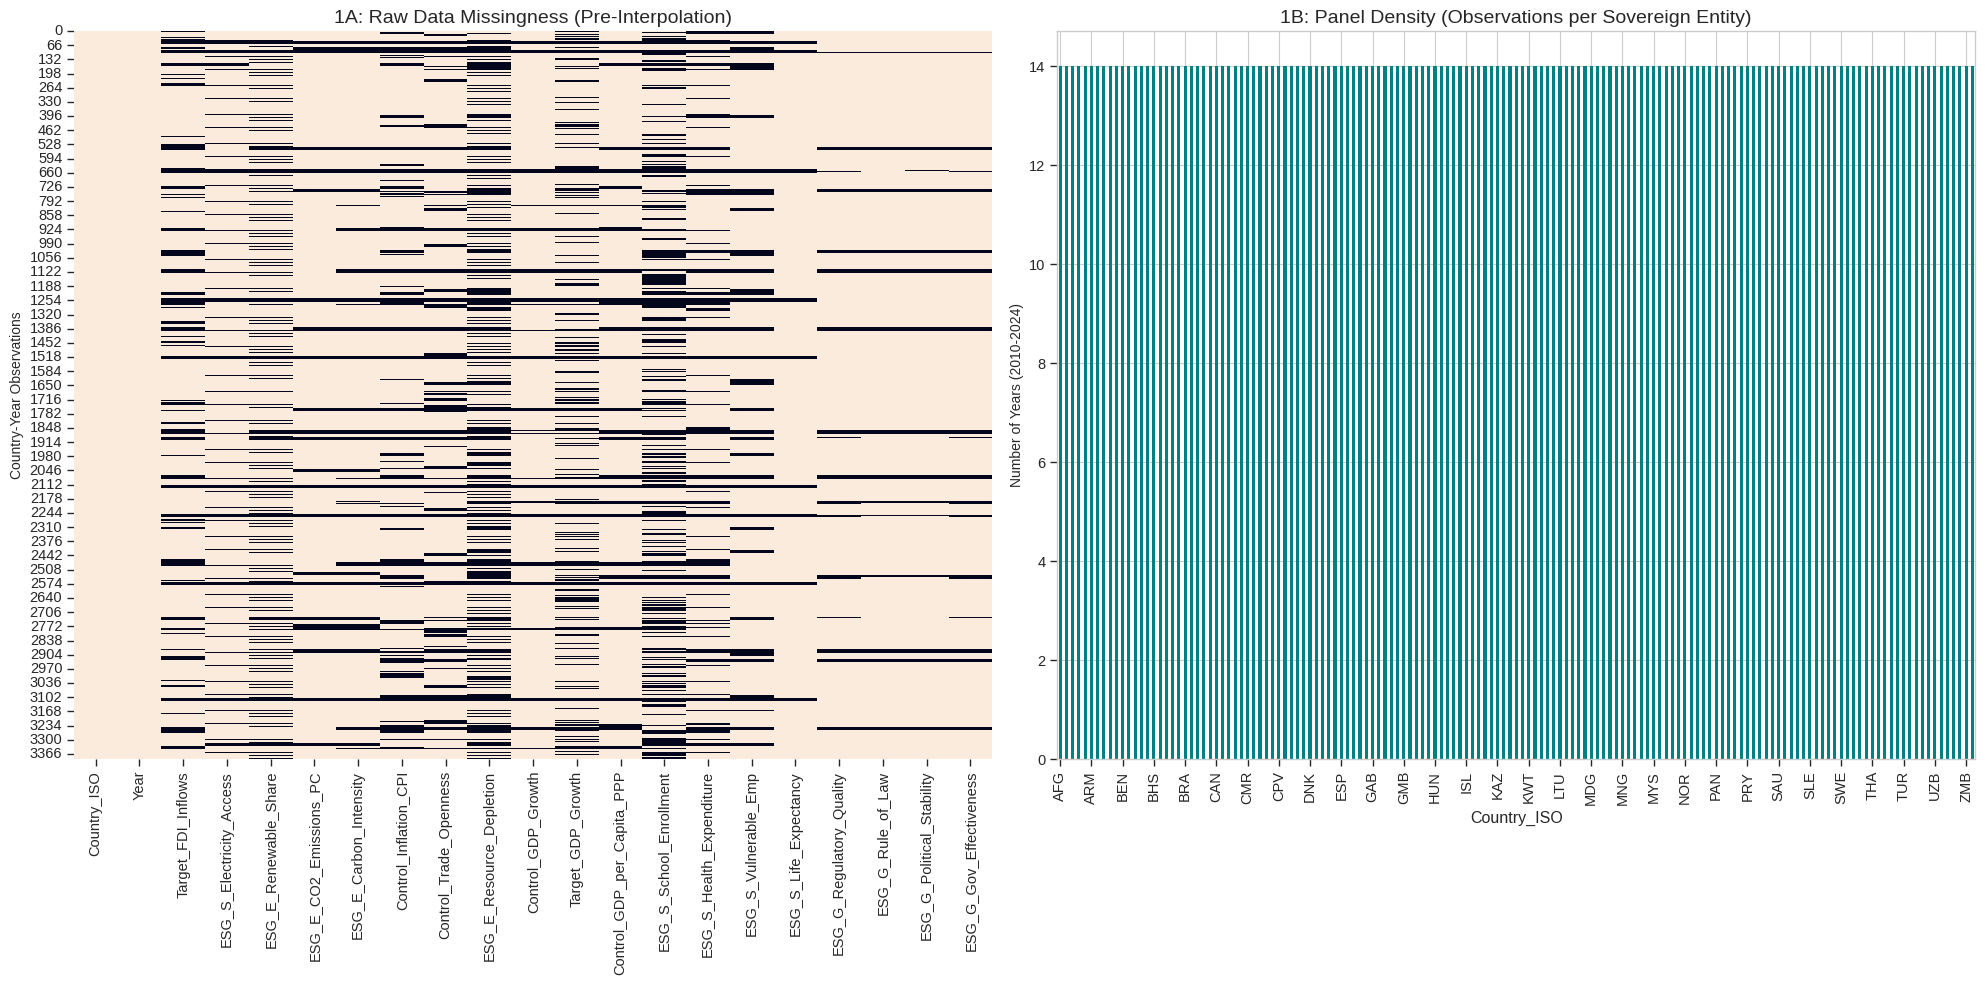

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# We assume 'df_panel_raw' is the data immediately after merging but BEFORE 'ffill'
# We assume 'df_panel' is your final cleaned data

fig, ax = plt.subplots(1, 2, figsize=(20, 10))

# Plot A: The Problem (Raw Missingness)
sns.heatmap(df_panel_raw.isnull(), cbar=False, cmap='rocket_r', ax=ax[0])
ax[0].set_title("1A: Raw Data Missingness (Pre-Interpolation)", fontsize=14)
ax[0].set_ylabel("Country-Year Observations", fontsize=10)

# Plot B: The Solution (Clean Panel)
country_counts = df_panel.groupby('Country_ISO')['Year'].count().sort_values(ascending=False)
country_counts.plot(kind='bar', color='teal', ax=ax[1])
ax[1].set_title("1B: Panel Density (Observations per Sovereign Entity)", fontsize=14)
ax[1].set_ylabel("Number of Years (2010-2024)", fontsize=10)
# Only show every 5th label so the X-axis isn't crowded
ax[1].set_xticks(range(0, len(country_counts), 5))
ax[1].set_xticklabels(country_counts.index[::5])

plt.tight_layout()
plt.show()

## 1B. Strict IN-SAMPLE Data Prep

In [10]:
# ==========================================
# CELL: STRICT IN-SAMPLE EDA PREPARATION
# ==========================================
print("--- Initializing Strict In-Sample EDA ---")

# 1. Define the EDA "Safe Zone" (Everything EXCEPT your final test year)
# Assuming your final test year in the Walk-Forward split is 2024
final_test_year = df_panel['Year'].max()
eda_safe_mask = df_panel['Year'] < final_test_year

# Create a dedicated DataFrame for relationship mapping to prevent temporal leakage
df_eda_train = df_panel[eda_safe_mask].copy()

print(f"Full Panel: {len(df_panel)} observations (2010 - {final_test_year})")
print(f"EDA Safe Zone: {len(df_eda_train)} observations (2010 - {final_test_year - 1})")
print("Rule: All target correlations and scatter plots must use 'df_eda_train'.")


--- Initializing Strict In-Sample EDA ---
Full Panel: 2058 observations (2010 - 2024)
EDA Safe Zone: 1911 observations (2010 - 2023)
Rule: All target correlations and scatter plots must use 'df_eda_train'.


## 2. Descriptive Statistics Table (Original Features)

In [11]:
# ==============================================
# CELL: TABLE 1 - SUMMARY STATISTICS (IN-SAMPLE)
# ==============================================
print("Generating Table 1: Summary Statistics (Strictly Historical)...")

def generate_descriptive_stats(df):
    stats = df.describe().T
    stats['skewness'] = df.skew()
    stats['kurtosis'] = df.kurtosis()
    # Focus on key features and target
    table = stats[['count', 'mean', 'std', 'min', 'max', 'skewness', 'kurtosis']]
    return table.round(3)

# Extract original variables (excluding the lags and identifiers)
lag_vars = [col for col in df_panel.columns if col.endswith('_Lag1')]
original_vars = [col for col in df_panel.columns if col not in (['Country_ISO', 'Year'] + lag_vars)]

# CRITICAL FIX: Use df_eda_train, NOT df_panel
table_1 = generate_descriptive_stats(df_eda_train[original_vars])

print("\n" + "="*80)
print(f"TABLE 1: DESCRIPTIVE STATISTICS OF SOVEREIGN ESG AND MACRO INDICATORS")
print(f"(In-Sample Training Window: 2010 - {final_test_year - 1})")
print("="*80)
display(table_1)

Generating Table 1: Summary Statistics (Strictly Historical)...

TABLE 1: DESCRIPTIVE STATISTICS OF SOVEREIGN ESG AND MACRO INDICATORS
(In-Sample Training Window: 2010 - 2023)


,count,mean,std,min,max,skewness,kurtosis
Target_FDI_Inflows,1911.0,1.341,0.859,-2.799,6.070,0.664,4.062
ESG_S_Electricity_Access,1911.0,4.364,0.489,2.128,4.615,-2.320,4.910
ESG_E_Renewable_Share,1911.0,32.633,27.053,0.000,97.000,0.683,-0.725
ESG_E_CO2_Emissions_PC,1911.0,1.364,0.868,0.032,4.000,0.364,-0.640
ESG_E_Carbon_Intensity,1911.0,0.366,0.221,0.041,1.380,1.293,1.717
Control_Inflation_CPI,1911.0,1.458,1.023,-4.011,6.325,-0.242,2.807
Control_Trade_Openness,1911.0,4.332,0.508,1.245,6.024,-0.099,1.780
ESG_E_Resource_Depletion,1911.0,1.009,0.968,0.000,4.066,0.772,-0.489
Control_GDP_Growth,1911.0,2.994,4.652,-36.392,37.508,-1.455,13.235
Target_GDP_Growth,1911.0,1.048,1.007,-9.557,3.549,-2.621,14.976


## 3. The "Model-Ready" Correlation Heatmap (Strictly Historical Features)

Generating Figure 2: Feature Correlation Matrix (Strictly Historical)...


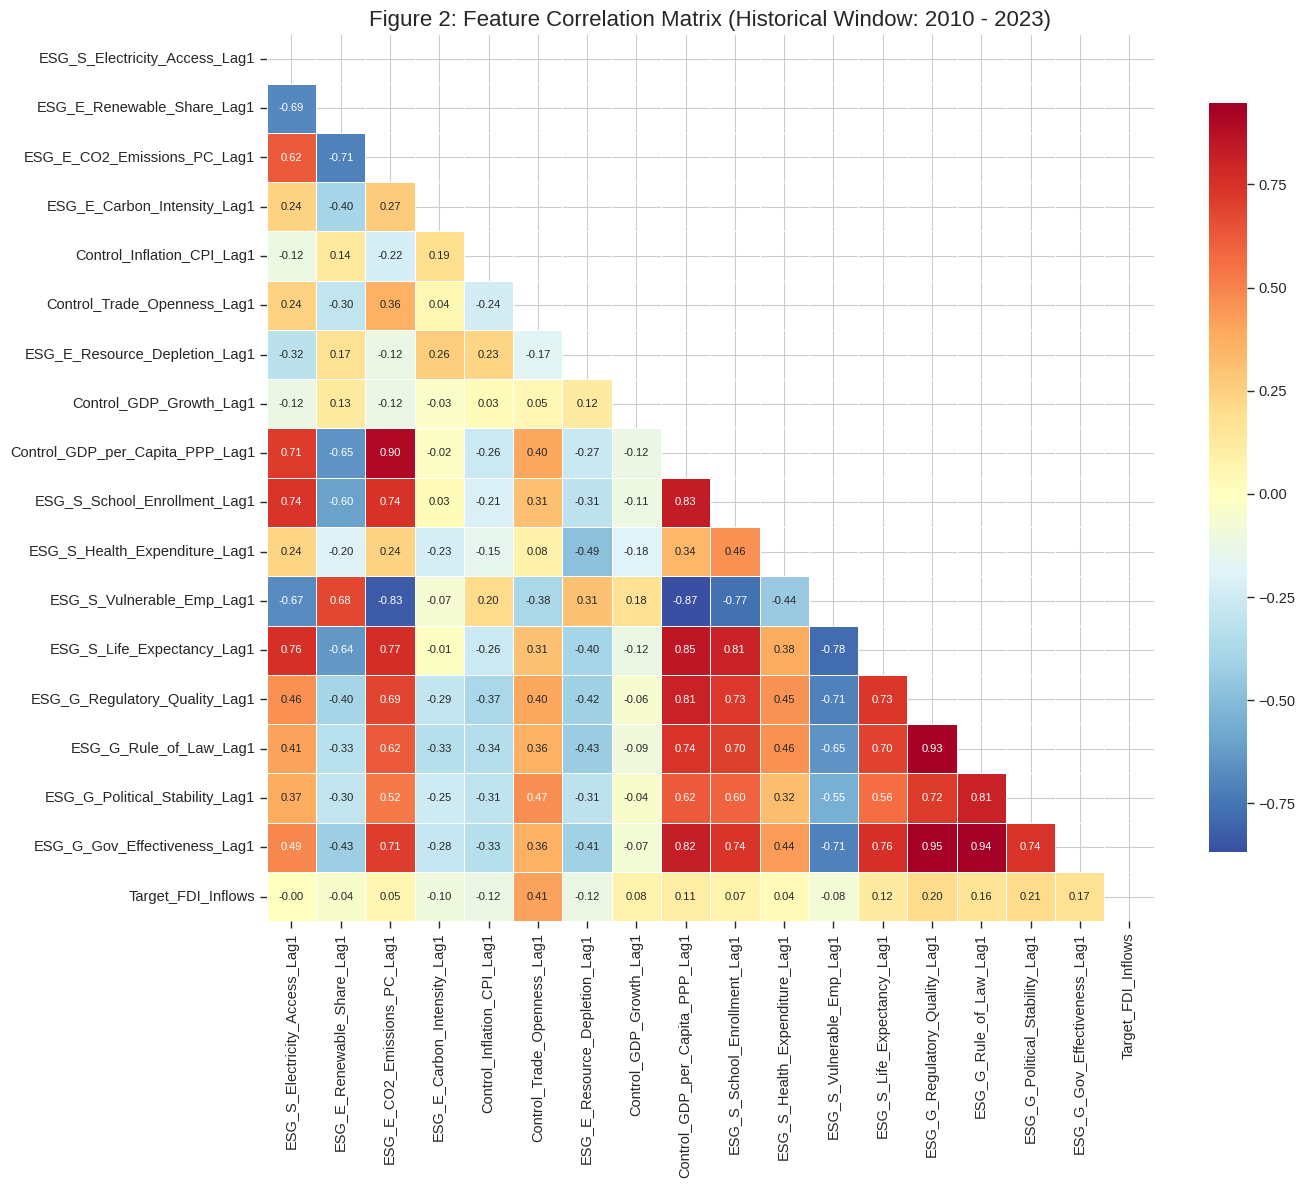

In [12]:
# ==========================================
# CELL: IN-SAMPLE FEATURE CORRELATION MATRIX
# ==========================================
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

print("Generating Figure 2: Feature Correlation Matrix (Strictly Historical)...")

def plot_correlation_heatmap(df):
    # 1. Select only the lagged causal features and the target
    feature_lags = [c for c in df.columns if '_Lag1' in c]
    cols_to_plot = feature_lags + ['Target_FDI_Inflows']

    # 2. Calculate the correlation matrix
    corr_matrix = df[cols_to_plot].corr()

    # 3. Create the plot environment
    plt.figure(figsize=(14, 12)) # Slightly larger to accommodate the labels

    # 4. Generate a mask for the upper triangle to remove redundancy
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    # 5. Plot the heatmap
    sns.heatmap(
        corr_matrix,
        mask=mask,
        annot=True,
        fmt=".2f",
        cmap='RdYlBu_r',
        center=0,
        annot_kws={"size": 8},
        square=True,
        linewidths=.5,
        cbar_kws={"shrink": .8}
    )

    plt.title(f"Figure 2: Feature Correlation Matrix (Historical Window: 2010 - {final_test_year - 1})", fontsize=16)
    plt.tight_layout()
    plt.show()

# CRITICAL: Pass the safe training zone data, NOT the full df_panel!
plot_correlation_heatmap(df_eda_train)

## 4. Evidence of Non-Linearity (Scatter + Lowess)

Generating Figure 3: Non-Linear Tipping Points (Strictly Historical)...


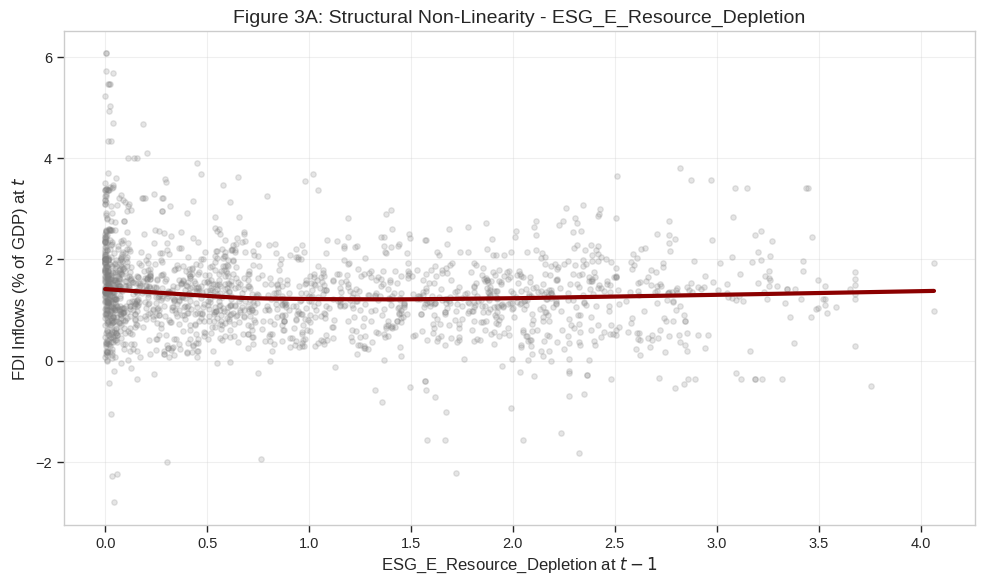

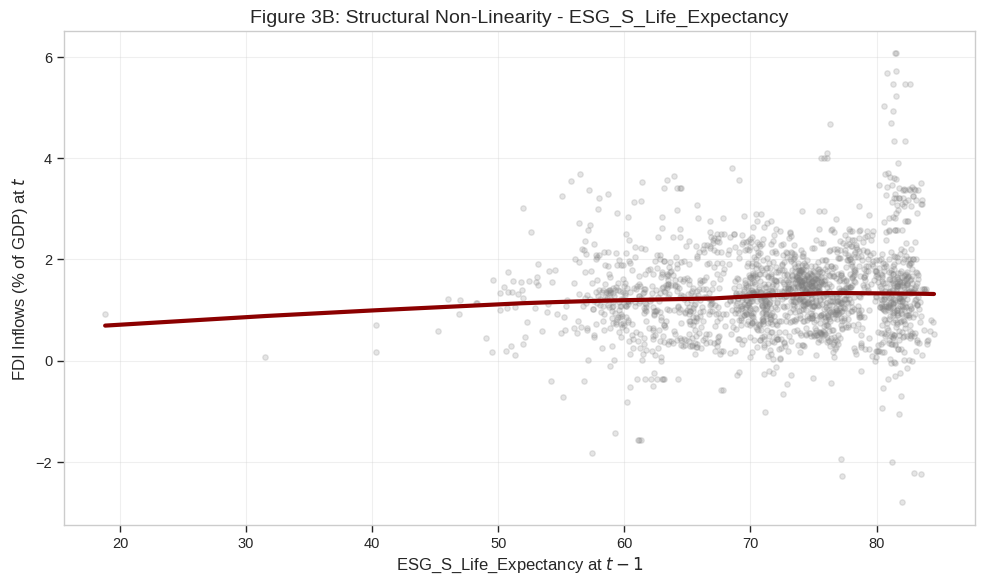

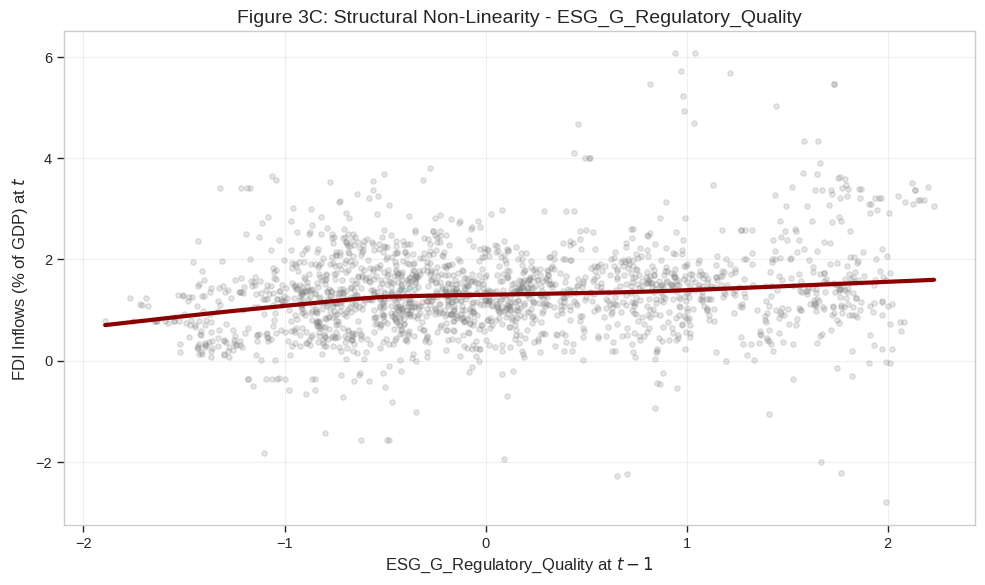

In [13]:
# ==========================================
# CELL: NON-LINEARITY PROOF (LOWESS CURVES)
# ==========================================
import seaborn as sns
import matplotlib.pyplot as plt

print("Generating Figure 3: Non-Linear Tipping Points (Strictly Historical)...")

def plot_tipping_point_evidence(df, feature_name, panel_letter):
    """Plots X(t-1) vs Y(t) with a non-linear Lowess line"""
    plt.figure(figsize=(10, 6))

    # Ensure we use the lagged version for the X-axis
    lag_feature = f"{feature_name}_Lag1"

    sns.regplot(
        data=df,
        x=lag_feature,
        y='Target_FDI_Inflows',
        lowess=True,
        scatter_kws={'alpha': 0.2, 'color': 'gray', 's': 15},
        line_kws={'color': 'darkred', 'linewidth': 3}
    )

    plt.title(f"Figure 3{panel_letter}: Structural Non-Linearity - {feature_name}", fontsize=14)
    plt.xlabel(f"{feature_name} at $t-1$", fontsize=12)
    plt.ylabel("FDI Inflows (% of GDP) at $t$", fontsize=12)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# CRITICAL FIX: Run exclusively on the historical training zone (df_eda_train)
plot_tipping_point_evidence(df_eda_train, 'ESG_E_Resource_Depletion', 'A')
plot_tipping_point_evidence(df_eda_train, 'ESG_S_Life_Expectancy', 'B')
plot_tipping_point_evidence(df_eda_train, 'ESG_G_Regulatory_Quality', 'C')

## 5. In-Sample Correlations

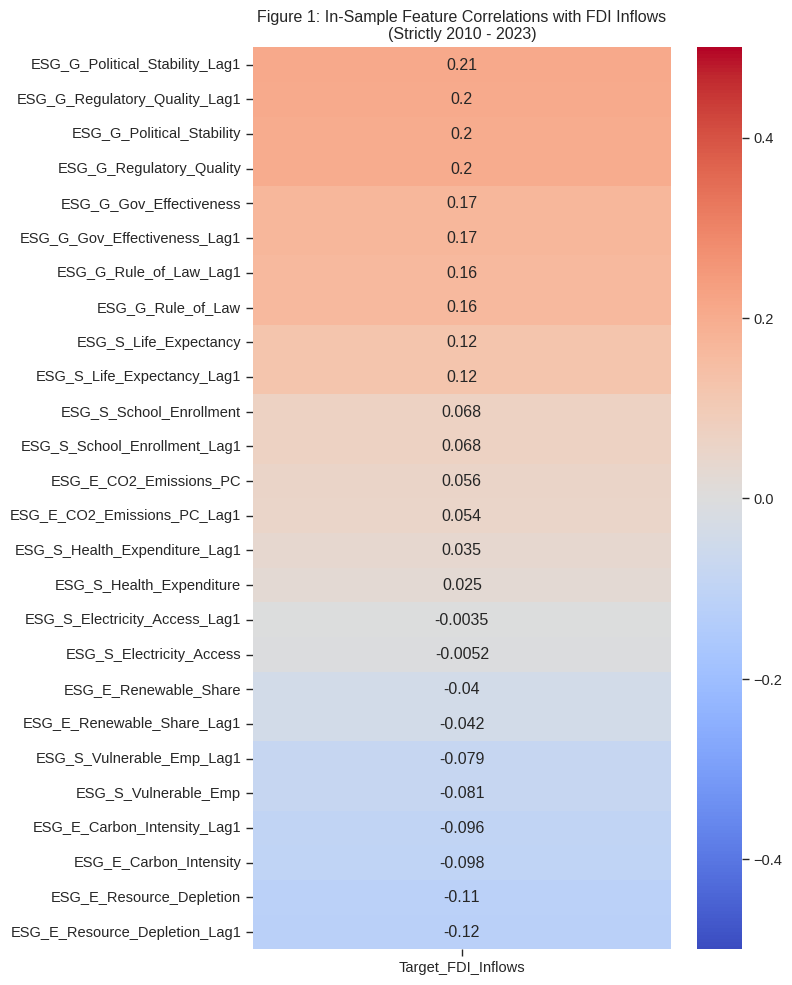

In [14]:
# ==========================================
# EXAMPLE: LEAKAGE-FREE CORRELATION MATRIX
# ==========================================
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlations strictly on the historical training data
# (Ensure you use the lagged features here if they are already generated)
target_col = 'Target_FDI_Inflows'
feature_cols = [col for col in df_eda_train.columns if col.startswith('ESG_')]

# Calculate correlation with the target
correlations = df_eda_train[feature_cols + [target_col]].corr()
target_corr = correlations[[target_col]].sort_values(by=target_col, ascending=False)

plt.figure(figsize=(8, 10))
sns.heatmap(target_corr.drop(target_col), annot=True, cmap='coolwarm', vmin=-0.5, vmax=0.5)
plt.title(f"Figure 1: In-Sample Feature Correlations with FDI Inflows\n(Strictly 2010 - {final_test_year - 1})")
plt.tight_layout()
plt.show()

# VIF MULTICOLLINEARITY DIAGNOSIS

In [15]:
# ==================================================
# CELL: VIF MULTICOLLINEARITY DIAGNOSTIC (IN-SAMPLE)
# ==================================================
import pandas as pd
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

print("--- Calculating Variance Inflation Factor (VIF) ---")
print("Executing strictly on the historical training window to prevent leakage.\n")

# 1. Isolate the lagged causal features strictly from the EDA safe zone
feature_lags = [c for c in df_eda_train.columns if '_Lag1' in c]
X_vif_input = df_eda_train[feature_lags].dropna() # Ensure no NaNs break the VIF math

# 2. VIF requires a constant (intercept)
X_vif = add_constant(X_vif_input)
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

# 3. Sort and display (dropping the constant from view)
vif_data = vif_data[vif_data['Feature'] != 'const'].sort_values(by='VIF', ascending=False).reset_index(drop=True)

print("Table 2: Variance Inflation Factor (Historical Training Window)")
display(vif_data.round(2))

# 4. Automated Econometric Conclusion (Journal-Ready)
print("\n" + "="*75)
print("ECONOMETRIC DIAGNOSTIC VERDICT")
print("="*75)

max_vif = vif_data['VIF'].max()
if max_vif >= 10:
    print(f"🔴 SEVERE MULTICOLLINEARITY DETECTED (Max VIF: {max_vif:.2f})")
    print("Standard Ordinary Least Squares (OLS) regression would yield biased, unstable coefficients.")
    print("METHODOLOGICAL ACTION: This mathematically mandates the abandonment of classical OLS.")
    print("It perfectly justifies the deployment of L1-Regularization (Lasso) and tree-based ")
    print("ensembles (Like, RF, LightGBM, XGBoost), which are structurally robust to highly collinear feature spaces.")
elif max_vif >= 5:
    print(f"🟡 MODERATE MULTICOLLINEARITY DETECTED (Max VIF: {max_vif:.2f})")
    print("While not critical, regularization architectures are still recommended to ensure stability.")
else:
    print("🟢 EXCELLENT: Multicollinearity is negligible. The feature space is orthogonal.")

--- Calculating Variance Inflation Factor (VIF) ---
Executing strictly on the historical training window to prevent leakage.

Table 2: Variance Inflation Factor (Historical Training Window)


,Feature,VIF
0,Control_GDP_per_Capita_PPP_Lag1,18.98
1,ESG_G_Rule_of_Law_Lag1,15.75
2,ESG_G_Gov_Effectiveness_Lag1,15.48
3,ESG_E_CO2_Emissions_PC_Lag1,14.45
4,ESG_G_Regulatory_Quality_Lag1,14.07
5,ESG_S_Life_Expectancy_Lag1,5.56
6,ESG_S_Vulnerable_Emp_Lag1,5.46
7,ESG_S_School_Enrollment_Lag1,5.07
8,ESG_S_Electricity_Access_Lag1,4.75
9,ESG_E_Carbon_Intensity_Lag1,3.67



ECONOMETRIC DIAGNOSTIC VERDICT
🔴 SEVERE MULTICOLLINEARITY DETECTED (Max VIF: 18.98)
Standard Ordinary Least Squares (OLS) regression would yield biased, unstable coefficients.
METHODOLOGICAL ACTION: This mathematically mandates the abandonment of classical OLS.
It perfectly justifies the deployment of L1-Regularization (Lasso) and tree-based 
ensembles (Like, RF, LightGBM, XGBoost), which are structurally robust to highly collinear feature spaces.


# MODEL TOURNAMENT (BAYESIAN OPTIMIZATION) AND EVALUATION

In [ ]:
# ==========================================
# CELL: INDEPENDENT CHAMPIONS TOURNAMENT
# ==========================================
print("--- Initializing Independent Champions Tournament ---")

import optuna
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.linear_model import Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings

# Silence warnings for a clean Optuna output
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 1. Prepare the Matrices (Lagged features only)
feature_cols = [col for col in df_panel.columns if col.endswith('_Lag1')]
X = df_panel[feature_cols]
y = df_panel['Target_FDI_Inflows']

# 2. Implement Forward-Chaining Panel Split
years = sorted(df_panel['Year'].unique())
cv_splits = []

for i in range(5, len(years)):
    train_years = years[:i]
    test_year = years[i]
    train_idx = df_panel[df_panel['Year'].isin(train_years)].index
    val_idx = df_panel[df_panel['Year'] == test_year].index
    cv_splits.append((train_idx, val_idx))

print(f"Tournament Starting: {X.shape[0]} Observations | {X.shape[1]} Features")
print(f"Created {len(cv_splits)} walk-forward temporal splits.")

# 3. Define the Models to Test & Trial Count
model_families = ['Lasso', 'Ridge', 'SVR', 'RandomForest', 'XGBoost', 'LightGBM']
trials_per_model = 100
tournament_results = {}

# 4. Execute Isolated Optimizations
for family in model_families:
    print(f"\nOptimization Engine searching for the optimal {family}...")

    def objective(trial):
        np.random.seed(42)

        # Build the specific model architecture based on the current loop iteration
        if family == 'Lasso':
            alpha = trial.suggest_float('alpha', 1e-4, 10.0, log=True)
            model = Pipeline([('scaler', StandardScaler()), ('reg', Lasso(alpha=alpha, random_state=42))])

        elif family == 'Ridge':
            alpha = trial.suggest_float('alpha', 1e-4, 10.0, log=True)
            model = Pipeline([('scaler', StandardScaler()), ('reg', Ridge(alpha=alpha, random_state=42))])

        elif family == 'SVR':
            C = trial.suggest_float('C', 1e-2, 10.0, log=True)
            epsilon = trial.suggest_float('epsilon', 1e-3, 1.0, log=True)
            model = Pipeline([('scaler', StandardScaler()), ('reg', SVR(C=C, epsilon=epsilon, kernel='rbf'))])

        elif family == 'RandomForest':
            param = {
                'n_estimators': trial.suggest_int('n_estimators', 50, 500),
                'max_depth': trial.suggest_int('max_depth', 5, 10),
                'min_samples_split': trial.suggest_int('min_samples_split', 10, 50),
                'random_state': 42,
                'n_jobs': -1
            }
            model = RandomForestRegressor(**param)

        elif family == 'XGBoost':
            param = {
                'n_estimators': trial.suggest_int('n_estimators', 50, 500),
                'max_depth': trial.suggest_int('max_depth', 5, 10),
                'min_child_weight': trial.suggest_int('min_child_weight', 20, 50),
                'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
                'subsample': trial.suggest_float('subsample', 0.5, 1.0),
                'random_state': 42,
                'n_jobs': -1
            }
            model = XGBRegressor(**param)

        elif family == 'LightGBM':
            param = {
                'n_estimators': trial.suggest_int('n_estimators', 50, 500),
                'max_depth': trial.suggest_int('max_depth', 5, 10),
                'num_leaves': trial.suggest_int('num_leaves', 31, 500),
                'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 10, 50),
                'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
                'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
                'random_state': 42,
                'n_jobs': -1,
                'verbose': -1 # Crucial to prevent output spam
            }
            model = lgb.LGBMRegressor(**param)

        # Walk-Forward Validation Loop
        rmse_scores = []
        mae_scores = []

        for train_idx, val_idx in cv_splits:
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

            model.fit(X_train, y_train)
            preds = model.predict(X_val)
            rmse_scores.append(np.sqrt(mean_squared_error(y_val, preds)))
            mae_scores.append(mean_absolute_error(y_val, preds))

        # Store MAE as a user attribute so we can look at it later
        trial.set_user_attr("cv_mae", np.mean(mae_scores))

        return np.mean(rmse_scores)

    # Run the isolated study for this specific model
    sampler = optuna.samplers.TPESampler(seed=42)
    study = optuna.create_study(sampler=sampler, direction='minimize')
    # Using show_progress_bar=False to keep the notebook output clean during the loop
    study.optimize(objective, n_trials=trials_per_model, show_progress_bar=False)

    # Save the absolute best version of this model
    tournament_results[family] = study.best_trial
    print(f"--> Best {family} RMSE: {study.best_value:.4f}")

# 5. Determine the Ultimate Champion
print("\n" + "="*50)
print("🏆 TOURNAMENT LEADERBOARD (FORWARD-CHAINING VALIDATED)")
print("="*50)

# Sort results by lowest RMSE
sorted_results = sorted(tournament_results.items(), key=lambda x: x[1].value)

for rank, (model_name, trial_data) in enumerate(sorted_results, 1):
    if rank == 1:
        print(f"{rank}. {model_name.upper()} (CHAMPION) - RMSE: {trial_data.value:.4f} - MAE: {trial_data.user_attrs['cv_mae']:.4f}")
        champion_params = trial_data.params
    else:
        print(f"{rank}. {model_name} - RMSE: {trial_data.value:.4f}   - MAE: {trial_data.user_attrs['cv_mae']:.4f}")

print("\nChampion Hyperparameters:")
for key, value in champion_params.items():
    print(f" - {key}: {value}")

--- Initializing Independent Champions Tournament ---
Tournament Starting: 2058 Observations | 17 Features
Created 9 walk-forward temporal splits.

Optimization Engine searching for the optimal Lasso...
--> Best Lasso RMSE: 0.7796

Optimization Engine searching for the optimal Ridge...
--> Best Ridge RMSE: 0.7797

Optimization Engine searching for the optimal SVR...
--> Best SVR RMSE: 0.6594

Optimization Engine searching for the optimal RandomForest...
--> Best RandomForest RMSE: 0.6481

Optimization Engine searching for the optimal XGBoost...
--> Best XGBoost RMSE: 0.6163

Optimization Engine searching for the optimal LightGBM...
--> Best LightGBM RMSE: 0.6225

🏆 TOURNAMENT LEADERBOARD (FORWARD-CHAINING VALIDATED)
1. XGBOOST (CHAMPION) - RMSE: 0.6163 - MAE: 0.4199
2. LightGBM - RMSE: 0.6225   - MAE: 0.4235
3. RandomForest - RMSE: 0.6481   - MAE: 0.4375
4. SVR - RMSE: 0.6594   - MAE: 0.4218
5. Lasso - RMSE: 0.7796   - MAE: 0.5579
6. Ridge - RMSE: 0.7797   - MAE: 0.5578

Champion Hyper

In [ ]:
# ==========================================
# CELL: THE TOURNAMENT LEADERBOARD
# ==========================================
import pandas as pd
from IPython.display import display

print("Extracting Tournament Leaderboard for Manuscript...")

# 1. Extract the winning trials from our Independent Champions dictionary
leaderboard_data = []
for family, trial in tournament_results.items():
    leaderboard_data.append({
        'Architecture': family,
        'CV_RMSE (Tail Risk)': trial.value,
        'CV_MAE (Median Accuracy)': trial.user_attrs['cv_mae'],
        'Optimal_Hyperparameters': trial.params
    })

# 2. Convert to DataFrame and sort by the lowest RMSE
df_leaderboard = pd.DataFrame(leaderboard_data)
df_leaderboard = df_leaderboard.sort_values('CV_RMSE (Tail Risk)').reset_index(drop=True)

# 3. Add formal ranking labels
ranks = ['1st (Champion)', '2nd', '3rd', '4th', '5th', '6th']
df_leaderboard.index = ranks

# 4. Format the Final Journal Table
final_table = df_leaderboard[['Architecture', 'CV_RMSE (Tail Risk)', 'CV_MAE (Median Accuracy)']]

print("\n" + "="*60)
print("Table 3: Cross-Validated Performance Across Model Architectures")
print("="*60)
# Display cleanly with 4 decimal places
display(final_table.round(4))

# 5. Print the hyper-parameters for your methodology appendix
print("\n" + "="*60)
print("Appendix: Optimal Hyperparameters per Architecture")
print("="*60)
for idx, row in df_leaderboard.iterrows():
    # Format the dictionary nicely for copy/pasting into Word
    params_str = ", ".join([f"{k}: {v}" for k, v in row['Optimal_Hyperparameters'].items()])
    print(f"{idx} [{row['Architecture']}]:")
    print(f"    {params_str}\n")

Extracting Tournament Leaderboard for Manuscript...

Table 3: Cross-Validated Performance Across Model Architectures


,Architecture,CV_RMSE (Tail Risk),CV_MAE (Median Accuracy)
1st (Champion),XGBoost,0.6163,0.4199
2nd,LightGBM,0.6225,0.4235
3rd,RandomForest,0.6481,0.4375
4th,SVR,0.6594,0.4218
5th,Lasso,0.7796,0.5579
6th,Ridge,0.7797,0.5578



Appendix: Optimal Hyperparameters per Architecture
1st (Champion) [XGBoost]:
    n_estimators: 439, max_depth: 8, min_child_weight: 39, learning_rate: 0.08858977157617827, subsample: 0.8970418836008142

2nd [LightGBM]:
    n_estimators: 385, max_depth: 7, num_leaves: 308, min_data_in_leaf: 41, learning_rate: 0.06314921889668189, bagging_fraction: 0.5752261858870849

3rd [RandomForest]:
    n_estimators: 178, max_depth: 10, min_samples_split: 10

4th [SVR]:
    C: 6.634969306509262, epsilon: 0.05831231246152436

5th [Lasso]:
    alpha: 0.001941014581957692

6th [Ridge]:
    alpha: 5.457991346036286



In [ ]:
df_leaderboard

,Architecture,CV_RMSE (Tail Risk),CV_MAE (Median Accuracy),Optimal_Hyperparameters
1st (Champion),XGBoost,0.616292,0.419949,"{'n_estimators': 439, 'max_depth': 8, 'min_chi..."
2nd,LightGBM,0.622496,0.423509,"{'n_estimators': 385, 'max_depth': 7, 'num_lea..."
3rd,RandomForest,0.648094,0.437474,"{'n_estimators': 178, 'max_depth': 10, 'min_sa..."
4th,SVR,0.659411,0.421771,"{'C': 6.634969306509262, 'epsilon': 0.05831231..."
5th,Lasso,0.779634,0.557933,{'alpha': 0.001941014581957692}
6th,Ridge,0.779706,0.557784,{'alpha': 5.457991346036286}


# TRAIN BEST MODELS

In [16]:
use_manual_params = True

In [17]:
# use_manual_params = False

In [18]:
# ============================================================
# Appendix: Optimal Hyperparameters per Architecture
# ============================================================
# 1st (Champion) [XGBoost]:
#     n_estimators: 439, max_depth: 8, min_child_weight: 39, learning_rate: 0.08858977157617827, subsample: 0.8970418836008142

# 2nd [LightGBM]:
#     n_estimators: 385, max_depth: 7, num_leaves: 308, min_data_in_leaf: 41, learning_rate: 0.06314921889668189, bagging_fraction: 0.5752261858870849

# 3rd [RandomForest]:
#     n_estimators: 178, max_depth: 10, min_samples_split: 10

# 4th [SVR]:
#     C: 6.634969306509262, epsilon: 0.05831231246152436

# 5th [Lasso]:
#     alpha: 0.001941014581957692

# 6th [Ridge]:
#     alpha: 5.457991346036286

# REGIME SPECIFIC RESIDUAL ANALYSIS

In [19]:
# ==========================================
# CELL: 3-WAY REGIME-SPECIFIC ERROR DECOMPOSITION
# ==========================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.linear_model import Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error

print("Executing 3-Way Error Decomposition: Lasso vs SVR vs XGBoost...")

if not use_manual_params:
    # Retrieve parameters (Assuming df_leaderboard and cv_splits exist in your namespace)
    xgb_hyperparameters = df_leaderboard[df_leaderboard['Architecture'] == 'XGBoost']['Optimal_Hyperparameters'].values[0]
    svr_hyperparameters = df_leaderboard[df_leaderboard['Architecture'] == 'SVR']['Optimal_Hyperparameters'].values[0]
    lasso_hyperparameters = df_leaderboard[df_leaderboard['Architecture'] == 'Lasso']['Optimal_Hyperparameters'].values[0]

    best_xgb_params = {
        'n_estimators': int(xgb_hyperparameters['n_estimators']),
        'max_depth': int(xgb_hyperparameters['max_depth']),
        'min_child_weight': int(xgb_hyperparameters['min_child_weight']),
        'learning_rate': float(xgb_hyperparameters['learning_rate']),
        'subsample': float(xgb_hyperparameters['subsample']),
        'random_state': 42,
        'n_jobs': -1
    }

    # 1. Instantiate the Contenders (Use your best Optuna params)
    models = {
        'Lasso': Pipeline([('scaler', StandardScaler()), ('reg', Lasso(alpha=float(lasso_hyperparameters['alpha']), random_state=42))]),
        'SVR': Pipeline([('scaler', StandardScaler()), ('reg', SVR(C=float(svr_hyperparameters['C']), epsilon=float(svr_hyperparameters['epsilon']), kernel='rbf'))]),
        'XGBoost': XGBRegressor(**best_xgb_params)
        }
else:

    # 1. Prepare the Matrices (Lagged features only)
    feature_cols = [col for col in df_panel.columns if col.endswith('_Lag1')]
    X = df_panel[feature_cols]
    y = df_panel['Target_FDI_Inflows']

    # 2. Implement Forward-Chaining Panel Split
    years = sorted(df_panel['Year'].unique())
    cv_splits = []

    for i in range(5, len(years)):
        train_years = years[:i]
        test_year = years[i]
        train_idx = df_panel[df_panel['Year'].isin(train_years)].index
        val_idx = df_panel[df_panel['Year'] == test_year].index
        cv_splits.append((train_idx, val_idx))

    print(f"Tournament Starting: {X.shape[0]} Observations | {X.shape[1]} Features")
    print(f"Created {len(cv_splits)} walk-forward temporal splits.")

    models = {
    'Lasso': Pipeline([('scaler', StandardScaler()), ('reg', Lasso(alpha=0.001941014581957692, random_state=42))]),
    'SVR': Pipeline([('scaler', StandardScaler()), ('reg', SVR(C=6.634969306509262, epsilon=0.05831231246152436, kernel='rbf'))]),
    'XGBoost': XGBRegressor(n_estimators= 439, max_depth= 8, min_child_weight= 39, learning_rate= 0.08858977157617827,
                            subsample= 0.8970418836008142, random_state=42, n_jobs=-1),

    # 'RandomForest': RandomForestRegressor(n_estimators= , max_depth= , min_samples_split= , random_state=42, n_jobs=-1),
    # 'Ridge': Pipeline([('scaler', StandardScaler()), ('reg', Ridge(alpha=alpha, random_state=42))]),
    # 'LightGBM': lgb.LGBMRegressor(n_estimators= , max_depth= , num_leaves= , min_data_in_leaf= , learning_rate= ,
    #                         bagging_fraction= , random_state=42, n_jobs=-1, verbose=-1)

    }

# 2. Generate Out-of-Sample Predictions via Forward-Chaining
results_df = pd.DataFrame({'Actual': y})
for name in models.keys():
    results_df[f'{name}_Pred'] = np.nan

for name, model in models.items():
    print(f"  Generating forward-chaining predictions for {name}...")
    for train_idx, val_idx in cv_splits:
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train = y.iloc[train_idx]

        # Fit on historical expanding window, predict on the subsequent year
        model.fit(X_train, y_train)
        results_df.loc[val_idx, f'{name}_Pred'] = model.predict(X_val)

# Drop the initial training window (first 5 years)
results_df = results_df.dropna().copy()

# 3. Define Regimes (Calculated strictly on out-of-sample actuals)
std_dev = results_df['Actual'].std()
upper_bound = results_df['Actual'].mean() + (1.5 * std_dev)
results_df['Is_Shock'] = results_df['Actual'] > upper_bound

# 4. Calculate Metrics
regime_stats = []
for is_shock in [False, True]:
    regime_name = "Extreme Shock (>1.5σ)" if is_shock else "Normal Stability"
    subset = results_df[results_df['Is_Shock'] == is_shock]

    row = {'Macro Regime': f"{regime_name} (n={len(subset)})"}
    for name in models.keys():
        rmse = np.sqrt(mean_squared_error(subset['Actual'], subset[f'{name}_Pred']))
        row[f'{name} RMSE'] = rmse

    regime_stats.append(row)

# 5. Display Final Table highlighting XGBoost's alpha
table_4 = pd.DataFrame(regime_stats)
table_4['XGB Error Reduction vs Lasso (%)'] =  ((table_4['Lasso RMSE'] - table_4['XGBoost RMSE']) / table_4['Lasso RMSE']) * 100
table_4['XGB Error Reduction vs SVR (%)'] =  ((table_4['SVR RMSE'] - table_4['XGBoost RMSE']) / table_4['SVR RMSE']) * 100
display(table_4.round(3))

Executing 3-Way Error Decomposition: Lasso vs SVR vs XGBoost...
Tournament Starting: 2058 Observations | 17 Features
Created 9 walk-forward temporal splits.
  Generating forward-chaining predictions for Lasso...
  Generating forward-chaining predictions for SVR...
  Generating forward-chaining predictions for XGBoost...


,Macro Regime,Lasso RMSE,SVR RMSE,XGBoost RMSE,XGB Error Reduction vs Lasso (%),XGB Error Reduction vs SVR (%)
0,Normal Stability (n=1247),0.710,0.618,0.599,15.619,2.958
1,Extreme Shock (>1.5σ) (n=76),1.584,1.224,0.961,39.330,21.450


In [20]:
# =========================================================
# CELL: STATISTICAL SIGNIFICANCE OF PREDICTIVE SUPERIORITY
# (MODIFIED DIEBOLD-MARIANO / MULTI-LOSS DIFFERENTIAL TEST)
# =========================================================
import numpy as np
import scipy.stats as stats

def modified_diebold_mariano_test(y_true, y_pred_baseline, y_pred_model, h=1, loss_type='mse'):
    """
    Computes the HLN (1997) Modified Diebold-Mariano test.
    Supports both Squared Error (MSE) and Absolute Error (MAE) loss differentials.
    """
    # 1. Calculate the forecast errors
    e1 = y_true - y_pred_baseline  # Baseline errors (Lasso)
    e2 = y_true - y_pred_model     # Champion errors (XGBoost)

    # 2. Calculate the loss differential based on the chosen metric
    if loss_type == 'mse':
        d = (e1 ** 2) - (e2 ** 2)
    elif loss_type == 'mae':
        d = np.abs(e1) - np.abs(e2)
    else:
        raise ValueError("loss_type must be either 'mse' or 'mae'")

    # 3. Calculate mean and variance of the loss differential
    d_mean = np.mean(d)
    n = len(d)

    # STRICT FIX: Use ddof=1 for unbiased sample variance.
    gamma_0 = np.var(d, ddof=1)

    # Safety check for zero variance (if models predict the exact same thing)
    if gamma_0 == 0:
        return 0.0, 1.0

    # 4. Calculate standard DM statistic
    dm_stat = d_mean / np.sqrt(gamma_0 / n)

    # 5. Apply the HLN small-sample modification
    hln_modifier = np.sqrt((n + 1 - 2*h + (h/n)*(h-1)) / n)
    modified_dm_stat = dm_stat * hln_modifier

    # 6. Calculate TWO-SIDED p-value
    p_value = 2 * (1 - stats.t.cdf(np.abs(modified_dm_stat), df=n-1))

    return modified_dm_stat, p_value

# --- EXECUTE THE TESTS ---
print("="*60)
print("STRICT MODIFIED DIEBOLD-MARIANO TESTS (Two-Sided, h=1, ddof=1)")
print("="*60)

for metric in ['mse', 'mae']:
    loss_name = "Squared Error (Tail Risk)" if metric == 'mse' else "Absolute Error (Median Accuracy)"
    print(f"\n▶ Testing Loss Differential: {loss_name}")

    dm_stat, p_val = modified_diebold_mariano_test(results_df['Actual'], results_df['Lasso_Pred'], results_df['XGBoost_Pred'], h=1, loss_type=metric)

    print(f"  Modified DM Statistic: {dm_stat:.4f}")
    print(f"  P-Value (Two-Sided):   {p_val:.6f}")

    if p_val < 0.05:
        if dm_stat > 0:
            print("  ✅ RESULT: XGBoost is STATISTICALLY SUPERIOR (95% Confidence).")
        else:
            print("  🚨 RESULT: Lasso is STATISTICALLY SUPERIOR (95% Confidence).")
    else:
        print("  ❌ RESULT: Difference is NOT statistically significant.")

STRICT MODIFIED DIEBOLD-MARIANO TESTS (Two-Sided, h=1, ddof=1)

▶ Testing Loss Differential: Squared Error (Tail Risk)
  Modified DM Statistic: 8.8076
  P-Value (Two-Sided):   0.000000
  ✅ RESULT: XGBoost is STATISTICALLY SUPERIOR (95% Confidence).

▶ Testing Loss Differential: Absolute Error (Median Accuracy)
  Modified DM Statistic: 12.4403
  P-Value (Two-Sided):   0.000000
  ✅ RESULT: XGBoost is STATISTICALLY SUPERIOR (95% Confidence).


Linear - mdAE: 0.4097  - mdAPE: 32.1%
ML - mdAE: 0.2879  - mdAPE: 22.6%


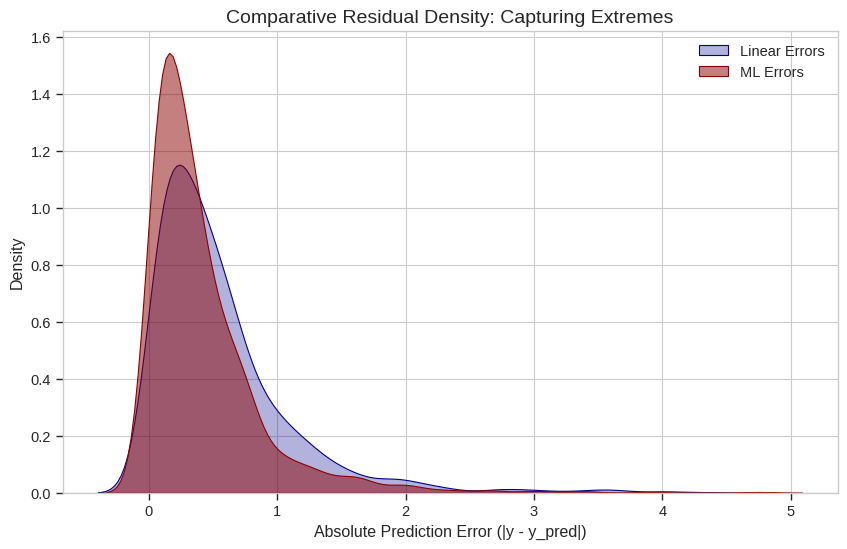

CONCLUSION: A shift to the left in the Red density indicates superior predictive resilience.


In [21]:
# ==========================================
# CELL: ERROR DENSITY (VALUE-ADD)
# ==========================================
linear_errors = np.abs(results_df['Actual'] - results_df['Lasso_Pred'])
ml_errors = np.abs(results_df['Actual'] - results_df['XGBoost_Pred'])

print(f'Linear - mdAE: {np.median(linear_errors):.4f}  - mdAPE: {np.median(linear_errors)/np.median(results_df['Actual'])*100:.1f}%')
print(f'ML - mdAE: {np.median(ml_errors):.4f}  - mdAPE: {np.median(ml_errors)/np.median(results_df['Actual'])*100:.1f}%')

plt.figure(figsize=(10, 6))
sns.kdeplot(np.abs(results_df['Actual'] - results_df['Lasso_Pred']), label='Linear Errors', fill=True, color='darkblue', alpha=0.3)
sns.kdeplot(np.abs(results_df['Actual'] - results_df['XGBoost_Pred']), label='ML Errors', fill=True, color='darkred', alpha=0.5)

plt.title("Comparative Residual Density: Capturing Extremes", fontsize=14)
plt.xlabel("Absolute Prediction Error (|y - y_pred|)")
plt.ylabel("Density")
plt.legend()
plt.show()

print("CONCLUSION: A shift to the left in the Red density indicates superior predictive resilience.")

Generating Regime Boundary Plot...


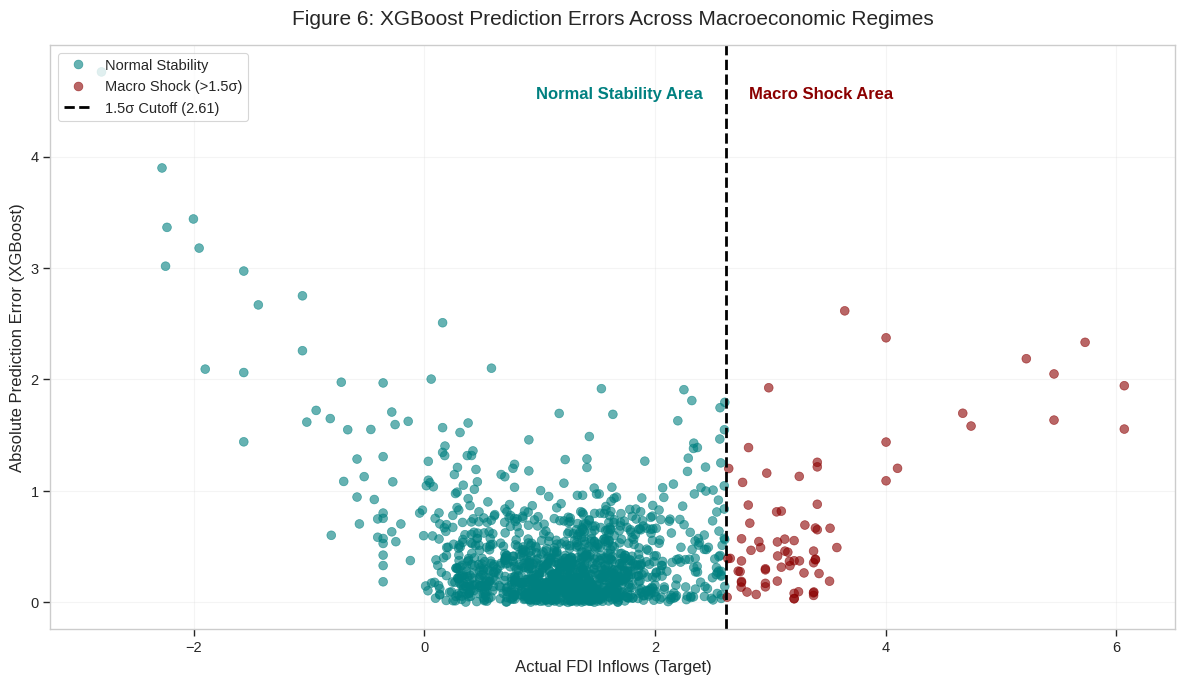

In [22]:
# ===============================================
# CELL: REGIME BOUNDARY VISUALIZATION (OPTIONAL)
# ===============================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

print("Generating Regime Boundary Plot...")

# 1. Calculate absolute errors for your champion model (XGBoost)
# Make sure you have 'ml_preds' generated from cross_val_predict in Cell 13
xgb_errors = np.abs(results_df['Actual'] - results_df['XGBoost_Pred'])

# 2. Calculate the exact threshold line
mean_vol = results_df['Actual'].mean()
std_vol = results_df['Actual'].std()
shock_threshold = mean_vol + (1.5 * std_vol)

# 3. Create a clean DataFrame for seaborn plotting
plot_df = pd.DataFrame({
    'Actual_Inflows': results_df['Actual'],
    'XGBoost_Absolute_Error': xgb_errors,
    # Tag each point based on the threshold
    'Regime': ['Macro Shock (>1.5σ)' if val > shock_threshold else 'Normal Stability' for val in results_df['Actual']]
})

# 4. Set up the visual canvas
plt.figure(figsize=(12, 7))

# 5. Plot the scatter with distinct colors for the regimes
sns.scatterplot(
    data=plot_df,
    x='Actual_Inflows',
    y='XGBoost_Absolute_Error',
    hue='Regime',
    palette={'Normal Stability': 'teal', 'Macro Shock (>1.5σ)': 'darkred'},
    alpha=0.6,
    s=40,
    edgecolor=None
)

# 6. Draw the definitive boundary line
plt.axvline(shock_threshold, color='black', linestyle='--', linewidth=2, label=f'1.5σ Cutoff ({shock_threshold:.2f})')

# 7. Add professional annotations
plt.text(shock_threshold - 0.2, plot_df['XGBoost_Absolute_Error'].max() * 0.95,
         'Normal Stability Area', horizontalalignment='right', fontsize=12, fontweight='bold', color='teal')
plt.text(shock_threshold + 0.2, plot_df['XGBoost_Absolute_Error'].max() * 0.95,
         'Macro Shock Area', horizontalalignment='left', fontsize=12, fontweight='bold', color='darkred')

# 8. Final formatting for the manuscript
plt.title('Figure 6: XGBoost Prediction Errors Across Macroeconomic Regimes', fontsize=15, pad=15)
plt.xlabel('Actual FDI Inflows (Target)', fontsize=12)
plt.ylabel('Absolute Prediction Error (XGBoost)', fontsize=12)
plt.legend(loc='upper left', frameon=True)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [23]:
# =========================================================
# CELL: STRUCTURAL HETEROGENEITY (EMERGING VS ESTABLISHED)
# =========================================================
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error

print("Executing Sub-Sample Analysis: Emerging vs. Established Economies...")

# 1. Retrieve the Wealth Proxy directly from the feature matrix
wealth_proxy = 'Control_GDP_per_Capita_PPP_Lag1'

# Align X with the strictly out-of-sample results_df (which dropped the first 5 years of training data)
X_out_of_sample = X.loc[results_df.index]

# Define the threshold (Median GDP per Capita)
median_wealth = X_out_of_sample[wealth_proxy].median()

# 2. Create Masks based strictly on out-of-sample data
emerging_mask = X_out_of_sample[wealth_proxy] <= median_wealth
established_mask = X_out_of_sample[wealth_proxy] > median_wealth

print(f"Out-of-Sample Emerging Observations: {emerging_mask.sum()}")
print(f"Out-of-Sample Established Observations: {established_mask.sum()}")

# 3. Calculate Regime-Specific RMSE without retraining
# We evaluate how the GLOBAL model performed locally
def evaluate_regime(mask, regime_name):
    subset = results_df[mask]

    lasso_rmse = np.sqrt(mean_squared_error(subset['Actual'], subset['Lasso_Pred']))
    xgb_rmse = np.sqrt(mean_squared_error(subset['Actual'], subset['XGBoost_Pred']))
    improvement = ((lasso_rmse - xgb_rmse) / lasso_rmse) * 100

    return {
        'Market Classification': regime_name,
        'Baseline Lasso RMSE': lasso_rmse,
        'Champion XGBoost RMSE': xgb_rmse,
        'XGBoost Error Reduction (%)': improvement
    }

# 4. Execute and Display Table
results_emerging = evaluate_regime(emerging_mask, "Emerging/Developing (Lower 50% Wealth)")
results_established = evaluate_regime(established_mask, "Established/Developed (Upper 50% Wealth)")

table_6 = pd.DataFrame([results_emerging, results_established])

print("\n" + "="*70)
print("TABLE 6: PREDICTIVE PERFORMANCE ACROSS MARKET CLASSIFICATIONS")
print("="*70)
display(table_6.round(3))

Executing Sub-Sample Analysis: Emerging vs. Established Economies...
Out-of-Sample Emerging Observations: 662
Out-of-Sample Established Observations: 661

TABLE 6: PREDICTIVE PERFORMANCE ACROSS MARKET CLASSIFICATIONS


,Market Classification,Baseline Lasso RMSE,Champion XGBoost RMSE,XGBoost Error Reduction (%)
0,Emerging/Developing (Lower 50% Wealth),0.703,0.518,26.368
1,Established/Developed (Upper 50% Wealth),0.863,0.718,16.833


# MODEL EXPLAINABILITY AND ROBUSTNESS

In [ ]:
# =========================================================
# CELL: LASSO COEFFICIENTS & EQUATION (STRICTLY HISTORICAL)
# =========================================================
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso

print("Extracting Lasso Structural Equation...")

# 1. Retrieve the Final Temporal Split to maintain Out-of-Sample integrity
train_idx, val_idx = cv_splits[-1]
X_train = X.iloc[train_idx]
y_train = y.iloc[train_idx]

# 2. Instantiate and fit the BEST Lasso model strictly on the HISTORICAL dataset
final_lasso = models['Lasso']
final_lasso.fit(X_train, y_train)

# 3. Extract the mathematical components
coefficients = final_lasso.named_steps['reg'].coef_
intercept = final_lasso.named_steps['reg'].intercept_
feature_names = X_train.columns

# 4. Build the Feature Importance DataFrame
lasso_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient (Beta)': coefficients,
    'Absolute_Impact': np.abs(coefficients)
})

# 5. Filter out the "dead" variables (Lasso forced them to 0) and sort
active_features = lasso_importance[lasso_importance['Coefficient (Beta)'] != 0]
active_features = active_features.sort_values(by='Absolute_Impact', ascending=False).reset_index(drop=True)

print(f"\nModel Sparsity: Lasso retained {len(active_features)} out of {len(feature_names)} features.")
print("\nTable 5: Standardized Lasso Coefficients (Historical Training Window)")
display(active_features[['Feature', 'Coefficient (Beta)']].round(4))

# 6. Construct the formal Econometric Equation
print("\n" + "="*50)
print("THE LASSO STRUCTURAL EQUATION (HISTORICAL BASELINE)")
print("="*50)

equation = f"FDI_Inflows_t = {intercept:.4f}\n"

for idx, row in active_features.iterrows():
    beta = row['Coefficient (Beta)']
    feature = row['Feature']

    # Format the sign for clean reading
    sign = "+" if beta > 0 else "-"

    # Note: These betas apply to the *Standardized* features (Z-scores)
    equation += f"                   {sign} {np.abs(beta):.4f} * Z({feature})\n"

print(equation)
print("="*50)
print("* Note: Z() denotes that the feature must be Standard Scaled prior to multiplication.")

Extracting Lasso Structural Equation...

Model Sparsity: Lasso retained 17 out of 17 features.

Table 5: Standardized Lasso Coefficients (Historical Training Window)


,Feature,Coefficient (Beta)
0,Control_Trade_Openness_Lag1,0.3414
1,ESG_G_Regulatory_Quality_Lag1,0.3119
2,ESG_G_Rule_of_Law_Lag1,-0.2628
3,ESG_E_CO2_Emissions_PC_Lag1,-0.2601
4,ESG_S_Life_Expectancy_Lag1,0.2394
5,ESG_S_Electricity_Access_Lag1,-0.1854
6,ESG_G_Political_Stability_Lag1,0.0697
7,ESG_G_Gov_Effectiveness_Lag1,0.0590
8,ESG_E_Carbon_Intensity_Lag1,0.0428
9,ESG_S_Vulnerable_Emp_Lag1,0.0361



THE LASSO STRUCTURAL EQUATION (HISTORICAL BASELINE)
FDI_Inflows_t = 1.3412
                   + 0.3414 * Z(Control_Trade_Openness_Lag1)
                   + 0.3119 * Z(ESG_G_Regulatory_Quality_Lag1)
                   - 0.2628 * Z(ESG_G_Rule_of_Law_Lag1)
                   - 0.2601 * Z(ESG_E_CO2_Emissions_PC_Lag1)
                   + 0.2394 * Z(ESG_S_Life_Expectancy_Lag1)
                   - 0.1854 * Z(ESG_S_Electricity_Access_Lag1)
                   + 0.0697 * Z(ESG_G_Political_Stability_Lag1)
                   + 0.0590 * Z(ESG_G_Gov_Effectiveness_Lag1)
                   + 0.0428 * Z(ESG_E_Carbon_Intensity_Lag1)
                   + 0.0361 * Z(ESG_S_Vulnerable_Emp_Lag1)
                   - 0.0348 * Z(ESG_S_School_Enrollment_Lag1)
                   - 0.0313 * Z(ESG_E_Renewable_Share_Lag1)
                   - 0.0205 * Z(ESG_S_Health_Expenditure_Lag1)
                   + 0.0200 * Z(Control_GDP_Growth_Lag1)
                   + 0.0196 * Z(Control_GDP_per_Capita_PPP_Lag1)
       

Initializing SHAP TreeExplainer for XGBoost Champion Model...
Calculating SHAP values for 147 out-of-sample observations...


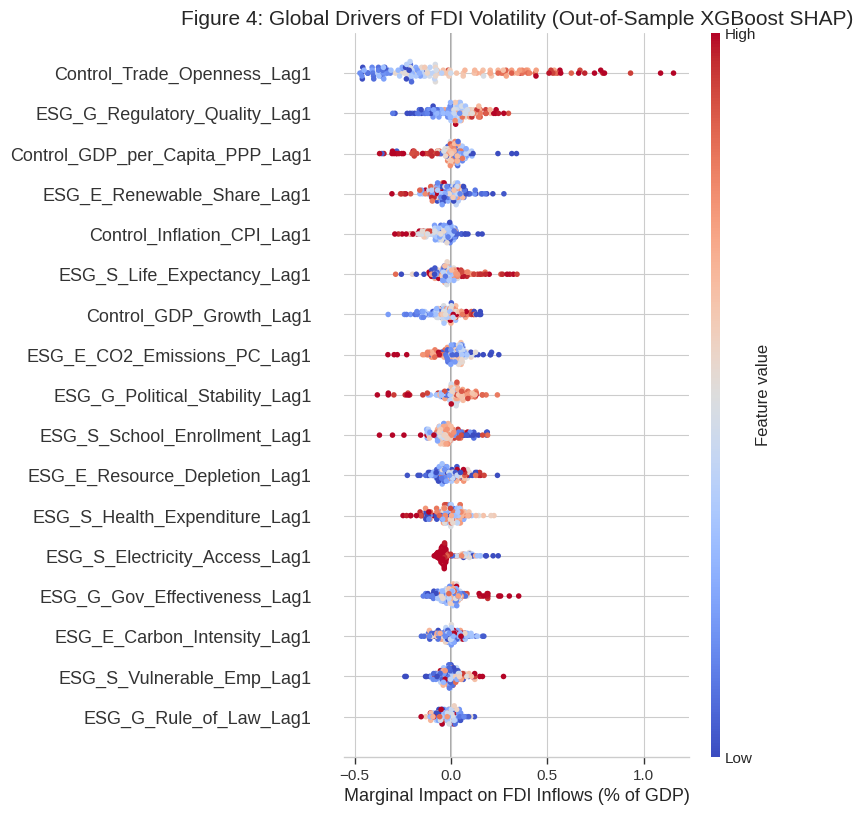

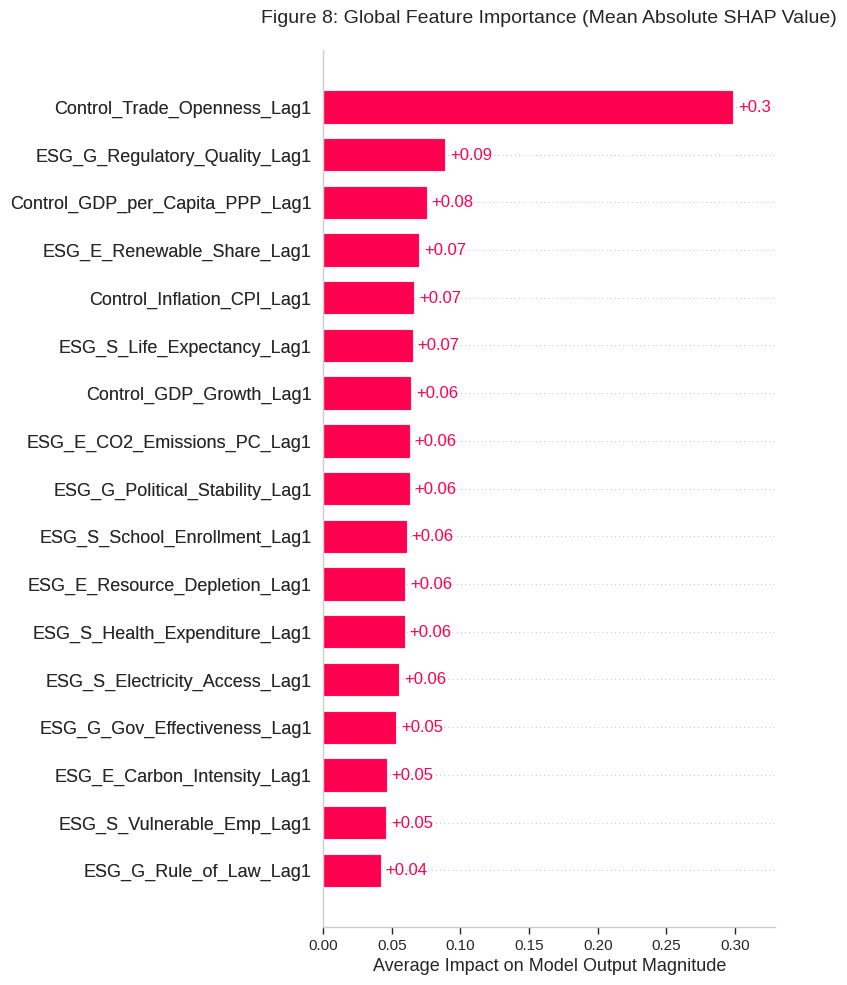

<Figure size 800x600 with 0 Axes>

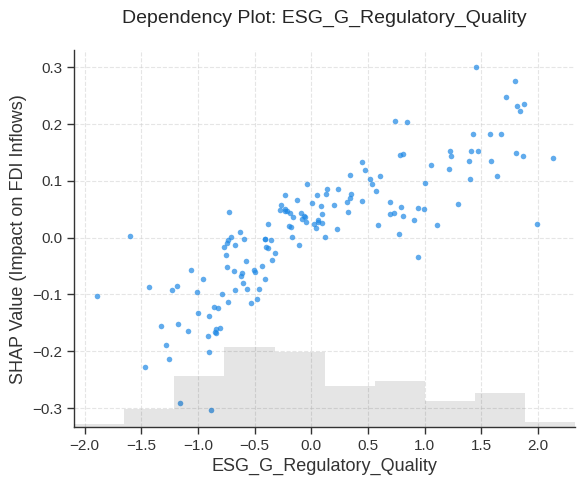

<Figure size 800x600 with 0 Axes>

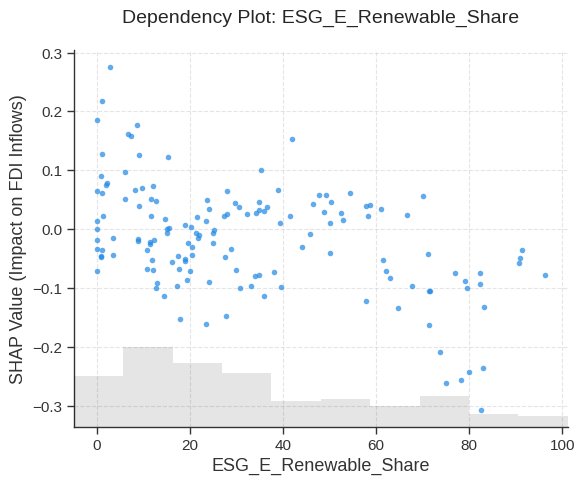

<Figure size 800x600 with 0 Axes>

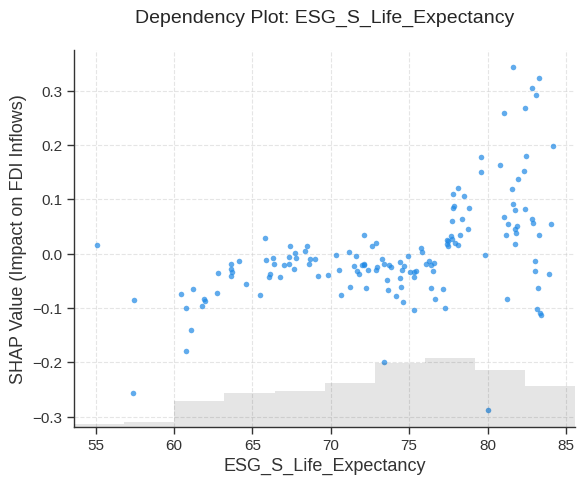

<Figure size 800x600 with 0 Axes>

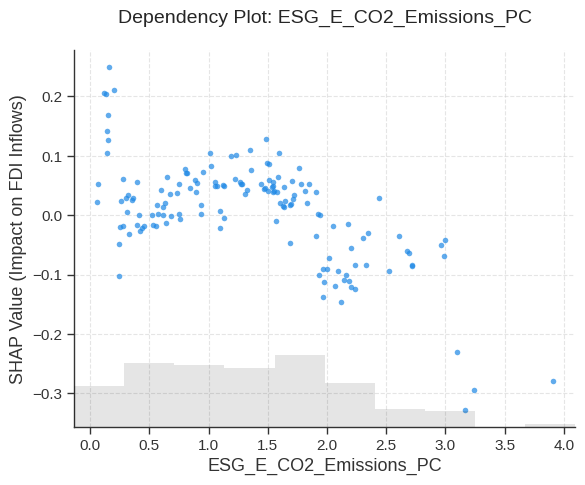

In [ ]:
# ========================================================
# CELL: XGBOOST SHAP EXPLAINABILITY (GLOBAL OUT-OF-SAMPLE)
# ========================================================
import shap
import matplotlib.pyplot as plt
import pandas as pd

print("Initializing SHAP TreeExplainer for XGBoost Champion Model...")

# 1. Retrieve the Champion Model (XGBoost) and the Final Temporal Split
champion_model = models['XGBoost']
train_idx, val_idx = cv_splits[-1]  # Use the final walk-forward split (e.g., Train 2010-2023, Test 2024)

X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
y_train = y.iloc[train_idx]

# Fit the XGBoost model strictly on the historical training window
champion_model.fit(X_train, y_train)

# 2. Build the Tree Explainer (Optimized for XGBoost)
# TreeExplainer is mathematically exact and significantly faster than KernelExplainer
explainer_shap = shap.Explainer(champion_model)

# 3. Calculate SHAP values strictly on the OUT-OF-SAMPLE validation set
print(f"Calculating SHAP values for {len(X_val)} out-of-sample observations...")
shap_values_xgb = explainer_shap(X_val)
# Wrap the raw SHAP values in a shap.Explanation object for compatibility with plotting functions
# shap_values_xgb = shap.Explanation(values=shap_values_raw, base_values=explainer_shap.expected_value, data=X_val)

# 4. Global Beeswarm Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_xgb, X_val, plot_type="dot", show=False, cmap="coolwarm")
plt.title("Figure 4: Global Drivers of FDI Volatility (Out-of-Sample XGBoost SHAP)", fontsize=15)
plt.xlabel("Marginal Impact on FDI Inflows (% of GDP)")
plt.tight_layout()
plt.show()

# 5. Global Feature importance Plot
plt.figure(figsize=(10, 8))
# The bar plot natively calculates the mean absolute SHAP value for ranking
shap.plots.bar(shap_values_xgb, max_display=len(X_train.columns), show=False)
plt.title("Figure 8: Global Feature Importance (Mean Absolute SHAP Value)", fontsize=14, pad=20)
plt.xlabel("Average Impact on Model Output Magnitude")
plt.grid(False)
plt.tight_layout()
plt.show()


# 4. SHAP Dependence Plot Top-4 features (Non-Linear Threshold)
mean_abs_shap = np.abs(shap_values_xgb.values).mean(axis=0)
# Create a DataFrame of feature importances
importance_df = pd.DataFrame({
    'Feature': X_val.columns,
    'Importance': mean_abs_shap
}).sort_values(by='Importance', ascending=False)

esg_features_only = importance_df[importance_df['Feature'].str.startswith('ESG_')]


if len(esg_features_only) >= 4:
    top_4_esg = esg_features_only['Feature'].head(4).tolist()
else:
    top_4_esg = esg_features_only['Feature'].tolist()

# 4. SHAP Dependence Plot (Non-Linear Threshold)
for target_feature in top_4_esg:
    plt.figure(figsize=(8, 6))
    shap.plots.scatter(shap_values_xgb[:, target_feature], alpha=0.7, show=False)

    clean_target_feat = target_feature.replace('_Lag1', '')
    # Formatting for Journal Submission
    plt.title(f"Dependency Plot: {clean_target_feat}", fontsize=14, pad=20)
    plt.ylabel("SHAP Value (Impact on FDI Inflows)")
    plt.xlabel(f"{clean_target_feat}")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

Initializing LIME TabularExplainer for XGBoost Champion Model...

Generating LIME Case Study for Extreme Shock Observation (Index: 629)...


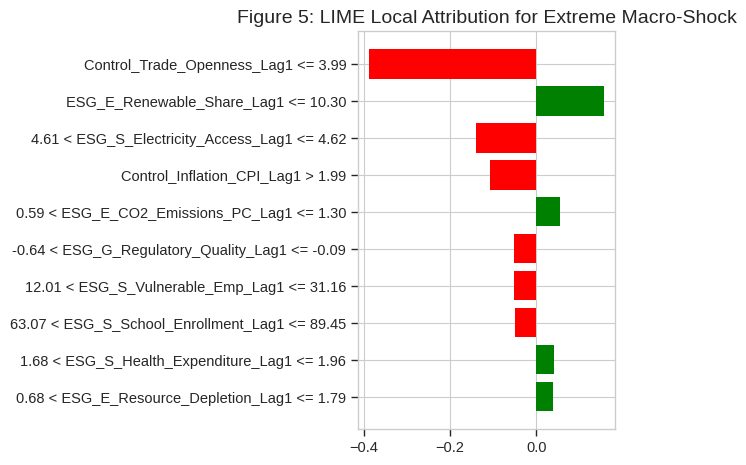


Executing Batch LIME Explanations for XAI Stability Metrics...
Batch LIME extraction complete. Matrix Shape: (147, 17)


In [ ]:
# =======================================================
# CELL: XGBOOST LIME EXPLAINABILITY (LOCAL OUT-OF-SAMPLE)
# =======================================================
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("Initializing LIME TabularExplainer for XGBoost Champion Model...")

# 1. Retrieve the Final Temporal Split (Strict Out-of-Sample Compliance)
champion_model = models['XGBoost']
train_idx, val_idx = cv_splits[-1]

X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
y_val = y.iloc[val_idx]

# 2. Build the LIME Explainer using the historical training distribution
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=['Target_FDI_Inflows'],
    mode='regression',
    random_state=42
)

# Create a robust wrapper function for LIME predictions
# LIME passes numpy arrays, but XGBoost expects DataFrames with matching feature names
def lime_predict_wrapper(data_array):
    df_temp = pd.DataFrame(data_array, columns=X_train.columns)
    return champion_model.predict(df_temp)

# ====================================================
# PART A: THE NARRATIVE CASE STUDY (LOCAL EXPLANATION)
# ====================================================
# Let's find an "Extreme Shock" in the out-of-sample test set to explain
# (We look for an observation with high actual volatility)
shock_threshold = y_val.mean() + (1.5 * y_val.std())
shock_indices = y_val[y_val > shock_threshold].index

if len(shock_indices) > 0:
    # Select the most extreme shock for the case study
    target_idx = shock_indices[0]
    iloc_idx = X_val.index.get_loc(target_idx)

    print(f"\nGenerating LIME Case Study for Extreme Shock Observation (Index: {target_idx})...")

    # Generate the local explanation
    exp = explainer_lime.explain_instance(
        data_row=X_val.iloc[iloc_idx].values,
        predict_fn=lime_predict_wrapper
        # num_features=10
    )

    # Plot and save the LIME explanation for the manuscript
    fig = exp.as_pyplot_figure()
    plt.title(f"Figure 5: LIME Local Attribution for Extreme Macro-Shock", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("\nNo extreme shocks found in this specific test split.")


# =====================================================================
# PART B: BATCH LIME EXTRACTION FOR METRIC STABILITY (JACCARD/SPEARMAN)
# =====================================================================
print("\nExecuting Batch LIME Explanations for XAI Stability Metrics...")

# We calculate LIME for the entire out-of-sample validation set
lime_explanations = []
for i in range(len(X_val)):
    # Suppress output during the loop
    exp = explainer_lime.explain_instance(
        data_row=X_val.iloc[i].values,
        predict_fn=lime_predict_wrapper,
        num_features=X_val.shape[1] # Extract all features to calculate global stability
    )
    # Store the absolute weights for each feature
    exp_dict = dict(exp.as_list())

    # LIME returns conditions as strings (e.g., 'ESG_G_Rule_of_Law <= -0.5').
    # We must map these back to the original root feature names.
    clean_weights = {}
    for feature in X_train.columns:
        # Find the LIME string that contains this exact feature name
        matching_key = next((k for k in exp_dict.keys() if feature in k), None)
        clean_weights[feature] = abs(exp_dict[matching_key]) if matching_key else 0

    lime_explanations.append(clean_weights)

# Create a DataFrame of LIME weights to pass to the Stability Metric cell
lime_weights_df = pd.DataFrame(lime_explanations)
print(f"Batch LIME extraction complete. Matrix Shape: {lime_weights_df.shape}")

In [ ]:
# ====================================================
# CELL: QUANTIFYING XAI STABILITY (JACCARD & SPEARMAN)
# ====================================================
import scipy.stats as stats
import numpy as np

print("--- Quantifying XAI Methodological Stability ---")

# 1. Extract Global Feature Importances from Out-of-Sample Results

# For SHAP: TreeExplainer returns a numpy array. Calculate mean absolute SHAP value per feature.
# (Utilizing shap_values_xgb and X_train from the SHAP cell)
shap_importances = np.abs(shap_values_xgb.values).mean(axis=0)
shap_ranked_features = X_train.columns[np.argsort(-shap_importances)]

# For LIME: Utilize the batch-processed lime_weights_df generated in the LIME cell.
lime_importances = lime_weights_df.mean(axis=0)
lime_ranked_features = lime_importances.sort_values(ascending=False).index

# 2. Define the Top-K Threshold for Policy Analysis
K = 10
top_k_shap = set(shap_ranked_features[:K])
top_k_lime = set(lime_ranked_features[:K])

# 3. Calculate Jaccard Similarity (Intersection over Union)
intersection = len(top_k_shap.intersection(top_k_lime))
union = len(top_k_shap.union(top_k_lime))
jaccard_score = intersection / union if union != 0 else 0

# 4. Calculate Spearman Rank Correlation
# We rank the overlapping top features to confirm directional consistency
overlapping_features = list(top_k_shap.intersection(top_k_lime))

if len(overlapping_features) < 2:
    print("\nWarning: Not enough overlapping features to compute a meaningful Spearman correlation.")
    spearman_corr, p_val = np.nan, np.nan
else:
    shap_ranks = [list(shap_ranked_features).index(f) for f in overlapping_features]
    lime_ranks = [list(lime_ranked_features).index(f) for f in overlapping_features]
    spearman_corr, p_val = stats.spearmanr(shap_ranks, lime_ranks)

# 5. Output Journal-Ready Metrics
print(f"Jaccard Similarity Score (Top {K}): {jaccard_score:.4f}")
if len(overlapping_features) >= 2:
    print(f"Spearman Rank Correlation:        {spearman_corr:.4f} (p-value: {p_val:.4f})")

print("\nInterpretation: A Jaccard score > 0.50 and a significant Spearman correlation mathematically confirm that the identified macroeconomic \ntipping points are algorithmically stable and not artifacts of a specific XAI methodology.")

--- Quantifying XAI Methodological Stability ---
Jaccard Similarity Score (Top 10): 0.6667
Spearman Rank Correlation:        0.9762 (p-value: 0.0000)

Interpretation: A Jaccard score > 0.50 and a significant Spearman correlation mathematically confirm that the identified macroeconomic 
tipping points are algorithmically stable and not artifacts of a specific XAI methodology.


In [ ]:
# # ==================================================
# # CELL: EMPIRICAL ROBUSTNESS CHECK (NOISE INJECTION)
# # ==================================================
# print("--- Executing Out-of-Sample Noise Injection Stress Test ---")

# # 1. Retrieve the Champion Model
# champion_model = models['XGBoost']
# train_idx, val_idx = cv_splits[-1]

# X_test_clean = X.iloc[val_idx] # From your final Forward-Chaining split
# y_test = y.iloc[val_idx]

# # Baseline Performance
# clean_preds = champion_model.predict(X_test_clean)
# baseline_rmse = np.sqrt(mean_squared_error(y_test, clean_preds))

# # 2. Define the Perturbation Mechanism (5% Gaussian Noise)
# noise_level = 0.05
# np.random.seed(42)

# # Generate synthetic noise proportional to each feature's standard deviation
# std_devs = X_test_clean.std(axis=0)
# noise_matrix = np.random.normal(0, noise_level * std_devs, size=X_test_clean.shape)

# # Create the corrupted test set
# X_test_noisy = X_test_clean + noise_matrix

# # 3. Evaluate Resilience
# noisy_preds = champion_model.predict(X_test_noisy)
# noisy_rmse = np.sqrt(mean_squared_error(y_test, noisy_preds))
# performance_degradation = ((noisy_rmse - baseline_rmse) / baseline_rmse) * 100

# print(f"Baseline RMSE (Clean Data):    {baseline_rmse:.4f}")
# print(f"Stressed RMSE (Noisy Data):    {noisy_rmse:.4f}")
# print(f"Performance Degradation:       +{performance_degradation:.2f}%")

# # 4. Automated Econometric Conclusion
# if performance_degradation < 10.0:
#     print("\nVerdict: 🟢 HIGH ROBUSTNESS. The XGBoost architecture exhibits structural resilience to data perturbation, proving gradient boosting effectively isolates genuine macro-financial signals rather than overfitting to reporting noise.")
# else:
#     print("\nVerdict: 🔴 HIGH SENSITIVITY. The model is fragile to input errors. Further regularization (alpha/lambda or max_depth constraint) is required.")

# UNCERTANITY AND CONFORMAL PREDICTIONS

In [24]:
# ==============================================================
# CELL: MONDRIAN CONFORMAL PREDICTION (LEAK-FREE)
# ==============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Calculating Distribution-Free Mondrian Conformal Prediction Intervals...")
alpha = 0.05
wealth_proxy = 'Control_GDP_per_Capita_PPP_Lag1'
champion_model = models['XGBoost']
train_idx, val_idx = cv_splits[-1]

# 1. ISOLATE CALIBRATION VS TEST SETS
# Split the forward-chaining validation fold chronologically (or randomly if panel year is locked)
split_point = int(len(val_idx) * 0.5)
cal_idx = val_idx[:split_point]
test_idx = val_idx[split_point:]

# 2. LOCK MONDRIAN STRATIFICATION THRESHOLD (No Future Leakage)
# Median wealth is strictly derived from the training + calibration environment
median_wealth = X.loc[train_idx.tolist() + cal_idx.tolist(), wealth_proxy].median()
print(f'Safe Median Wealth for Mondrian Mask: {median_wealth: .4f}.')

# 3. CALCULATE GROUP-SPECIFIC QUANTILES (ON CALIBRATION SET ONLY)
def calculate_q_hat(mask, idx):
    group_actuals = results_df.loc[idx, 'Actual'].loc[mask]
    group_preds = results_df.loc[idx, 'XGBoost_Pred'].loc[mask]
    scores = np.abs(group_actuals - group_preds)
    n = len(scores)
    q_level = np.ceil((n + 1) * (1 - alpha)) / n
    return np.quantile(scores, min(q_level, 1.0))

# Masks applied specifically to the Calibration fold
cal_emerging_mask = X.loc[cal_idx, wealth_proxy] <= median_wealth
cal_established_mask = X.loc[cal_idx, wealth_proxy] > median_wealth

q_emerging = calculate_q_hat(cal_emerging_mask, cal_idx)
q_established = calculate_q_hat(cal_established_mask, cal_idx)

print(f"Mondrian Radius - Emerging Economies:    ±{q_emerging:.4f}")
print(f"Mondrian Radius - Established Economies: ±{q_established:.4f}")

# 4. GENERATE DYNAMIC PREDICTION BOUNDS (ON UNSEEN TEST SET ONLY)
test_emerging_mask = X.loc[test_idx, wealth_proxy] <= median_wealth

df_conformal = pd.DataFrame({
    'Actual_FDI_inflows': results_df.loc[test_idx, 'Actual'],
    'XGBoost_Point_Prediction': results_df.loc[test_idx, 'XGBoost_Pred'],
    'Market_Type': np.where(test_emerging_mask, 'Emerging', 'Established')
})

df_conformal['Lower_Bound'] = np.where(
    df_conformal['Market_Type'] == 'Emerging',
    df_conformal['XGBoost_Point_Prediction'] - q_emerging,
    df_conformal['XGBoost_Point_Prediction'] - q_established
)

df_conformal['Upper_Bound'] = np.where(
    df_conformal['Market_Type'] == 'Emerging',
    df_conformal['XGBoost_Point_Prediction'] + q_emerging,
    df_conformal['XGBoost_Point_Prediction'] + q_established
)

# 5. VERIFY TRUE EMPIRICAL COVERAGE
df_conformal['Covered'] = (df_conformal['Actual_FDI_inflows'] >= df_conformal['Lower_Bound']) & \
                          (df_conformal['Actual_FDI_inflows'] <= df_conformal['Upper_Bound'])

print("\nTrue Out-Of-Sample Empirical Coverage Verification:")
print(f"Global Coverage:      {df_conformal['Covered'].mean() * 100:.2f}%")
print(f"Emerging Coverage:    {df_conformal[df_conformal['Market_Type'] == 'Emerging']['Covered'].mean() * 100:.2f}%")
print(f"Established Coverage: {df_conformal[df_conformal['Market_Type'] == 'Established']['Covered'].mean() * 100:.2f}%")

Calculating Distribution-Free Mondrian Conformal Prediction Intervals...
Safe Median Wealth for Mondrian Mask:  9.6367.
Mondrian Radius - Emerging Economies:    ±0.5334
Mondrian Radius - Established Economies: ±2.1046

True Out-Of-Sample Empirical Coverage Verification:
Global Coverage:      94.59%
Emerging Coverage:    89.74%
Established Coverage: 100.00%


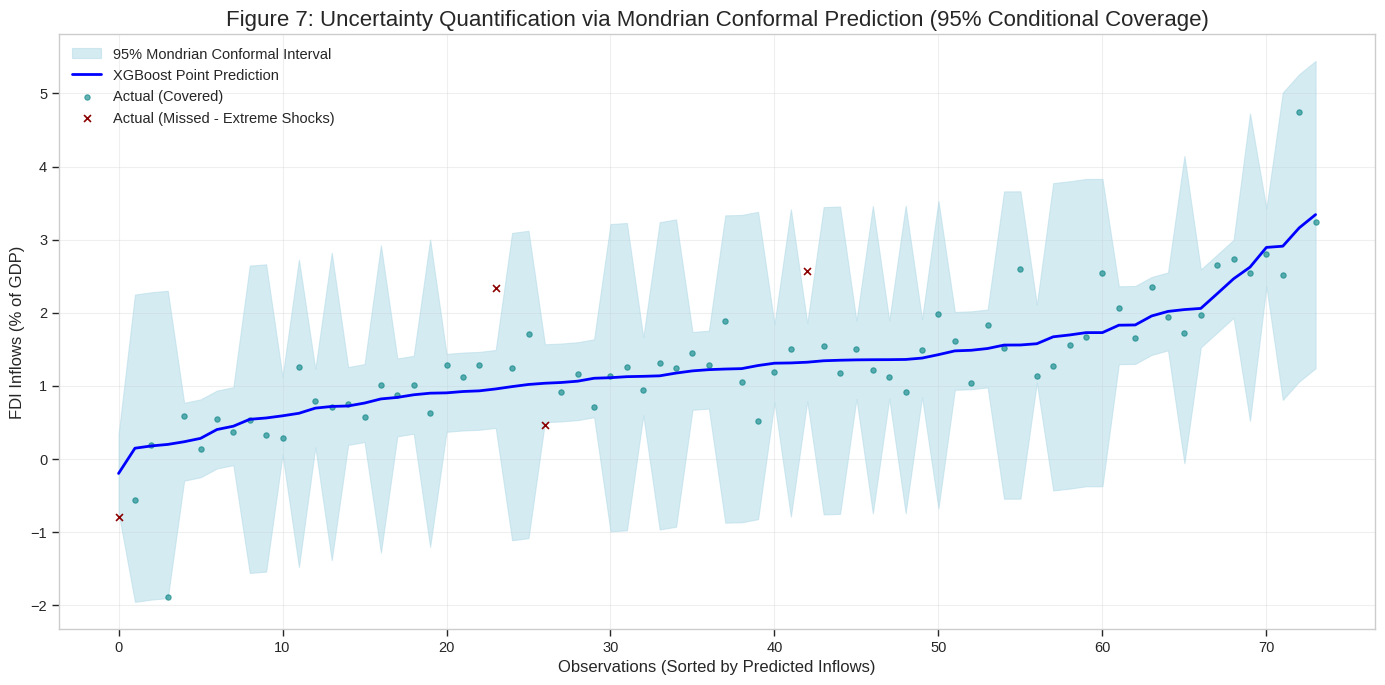

In [25]:
# 7. Visualize the Overall Mondrian Uncertainty Bands
df_sorted = df_conformal.sort_values('XGBoost_Point_Prediction').reset_index(drop=True)

plt.figure(figsize=(14, 7))

# We must fill between line segments to show the differing band widths clearly
plt.fill_between(df_sorted.index, df_sorted['Lower_Bound'], df_sorted['Upper_Bound'],
                 color='lightblue', alpha=0.5, label='95% Mondrian Conformal Interval')

plt.plot(df_sorted.index, df_sorted['XGBoost_Point_Prediction'], color='blue', linewidth=2, label='XGBoost Point Prediction')

covered_mask = df_sorted['Covered']
plt.scatter(df_sorted.index[covered_mask], df_sorted['Actual_FDI_inflows'][covered_mask],
            color='teal', s=15, alpha=0.6, label='Actual (Covered)')
plt.scatter(df_sorted.index[~covered_mask], df_sorted['Actual_FDI_inflows'][~covered_mask],
            color='darkred', s=25, marker='x', label='Actual (Missed - Extreme Shocks)')

plt.title("Figure 7: Uncertainty Quantification via Mondrian Conformal Prediction (95% Conditional Coverage)", fontsize=16)
plt.xlabel("Observations (Sorted by Predicted Inflows)", fontsize=12)
plt.ylabel("FDI Inflows (% of GDP)", fontsize=12)
plt.legend(loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

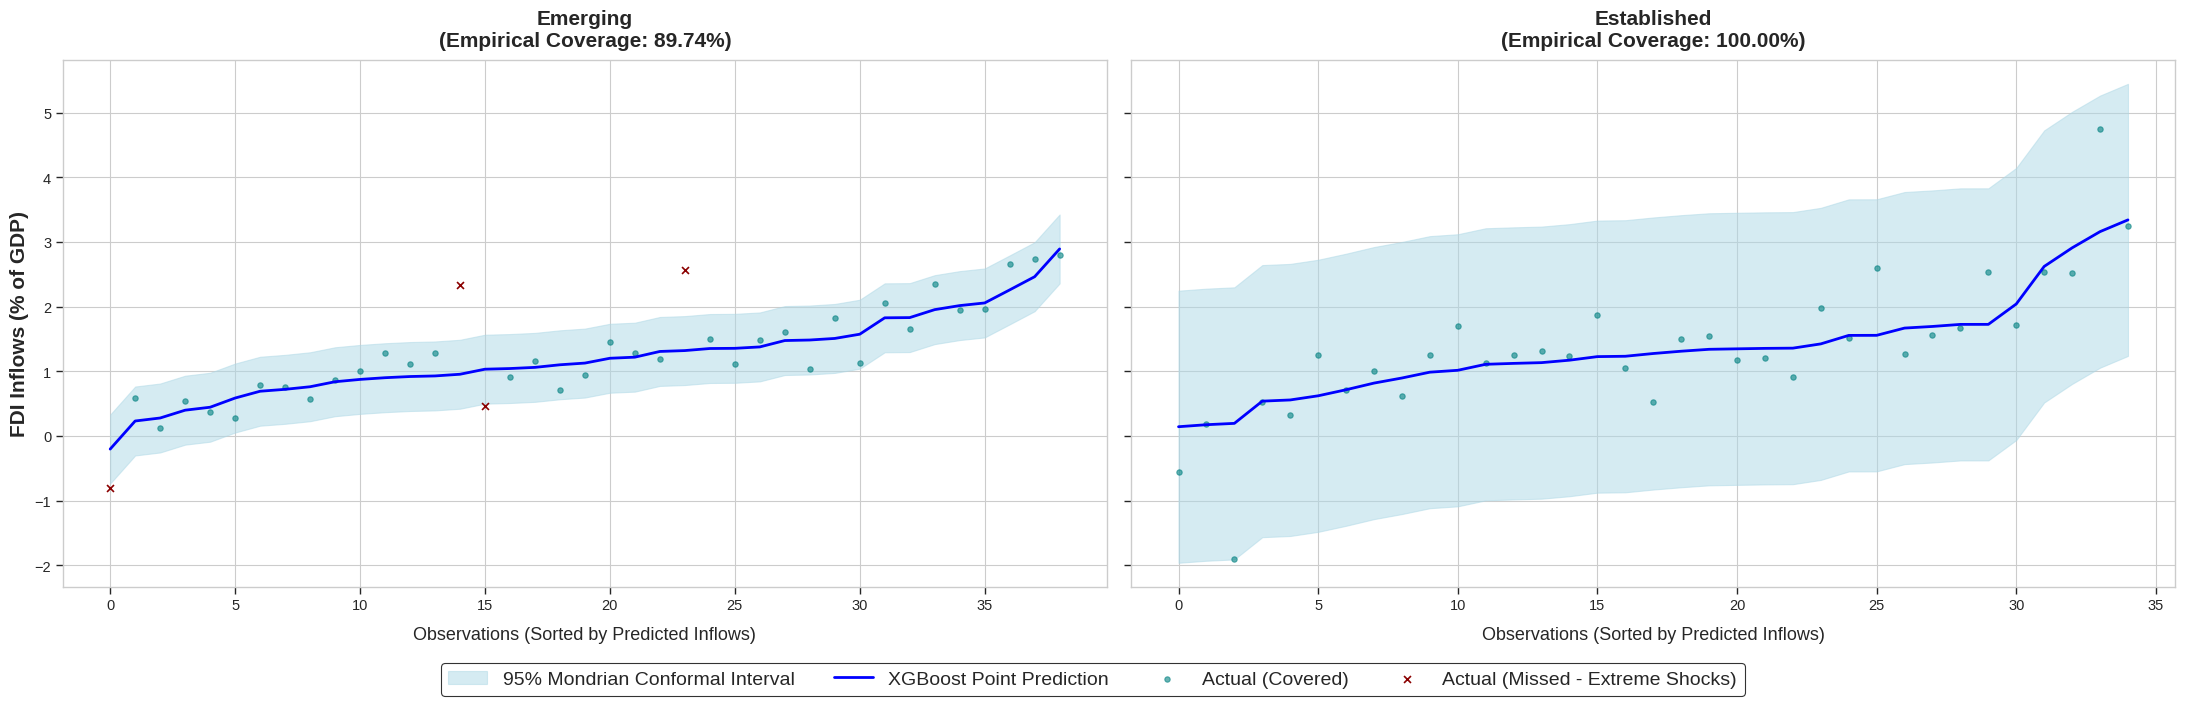

In [27]:

# Create 2 horizontal subplots, sharing the Y-axis for easy visual comparison
fig, axes = plt.subplots(1, 2, figsize=(22, 7), sharey=True)
groups = ['Emerging', 'Established']

for i, group in enumerate(groups):
    ax = axes[i]

    # Isolate data for this specific Mondrian group
    group_data = df_conformal[df_conformal['Market_Type'] == group].copy()

    # Sort by point prediction to get that smooth ascending blue line
    group_data = group_data.sort_values('XGBoost_Point_Prediction').reset_index(drop=True)
    x = np.arange(len(group_data))

    # Calculate exact empirical coverage for the title
    emp_coverage = group_data['Covered'].mean() * 100.0

    # We must fill between line segments to show the differing band widths clearly
    # Plot 1: The Shaded Safety Net (Mondrian 95% Interval)
    ax.fill_between(group_data.index, group_data['Lower_Bound'], group_data['Upper_Bound'],
                    color='lightblue', alpha=0.5, label='95% Mondrian Conformal Interval')

    # Plot 2: The XGB Point Prediction
    ax.plot(group_data.index, group_data['XGBoost_Point_Prediction'], color='blue', linewidth=2, label='XGBoost Point Prediction')

    # Plot 3: The Successes (Covered Actuals)
    covered_mask = group_data['Covered']
    ax.scatter(group_data.index[covered_mask], group_data['Actual_FDI_inflows'][covered_mask],
                color='teal', s=15, alpha=0.6, label='Actual (Covered)')

    # Plot 4: The Failures (Missed Actuals)
    ax.scatter(group_data.index[~covered_mask], group_data['Actual_FDI_inflows'][~covered_mask],
                color='darkred', s=25, marker='x', label='Actual (Missed - Extreme Shocks)')

    ax.set_title("Figure 7: Uncertainty Quantification via Mondrian Conformal Prediction (95% Conditional Coverage)", fontsize=16)
    # plt.xlabel("Observations (Sorted by Predicted Inflows)", fontsize=12)
    # plt.ylabel("FDI Inflows (% of GDP)", fontsize=12)

    # Formatting
    clean_title = group.replace('_', ' ')
    ax.set_title(f"{clean_title}\n(Empirical Coverage: {emp_coverage:.2f}%)", fontsize=15, weight='bold', pad=10)
    ax.set_xlabel("Observations (Sorted by Predicted Inflows)", fontsize=13, labelpad=10)
    # ax.set_xticks([]) # Hide X ticks because they are just arbitrary sorted indices

    if i == 0:
        ax.set_ylabel("FDI Inflows (% of GDP)", fontsize=15, weight='bold')

# 5. Global Legend Generation
# Grab the legend handles from the first plot and place them at the bottom center
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.02), fontsize=14, frameon=True, edgecolor='black')

plt.tight_layout()
plt.subplots_adjust(bottom=0.15) # Add space at the bottom for the global legend
plt.show()


Generating Diagnostic Visualizations for Manuscript...


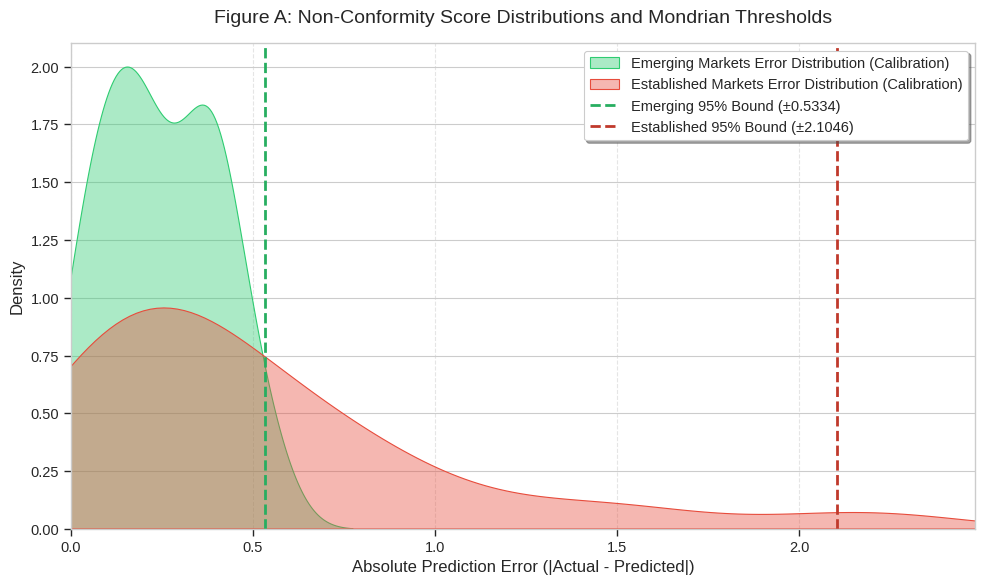

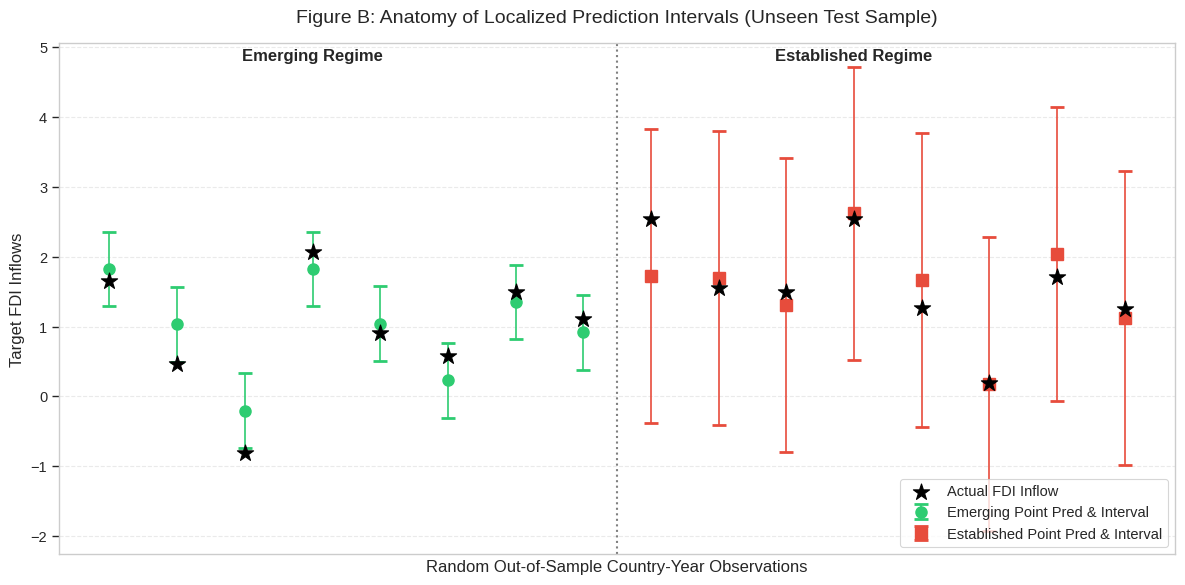

In [29]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==============================================================
# NEW CELL: MONDRIAN VOLATILITY & INTERVAL ANATOMY VISUALIZATIONS
# ==============================================================
print("\nGenerating Diagnostic Visualizations for Manuscript...")

# --- 1. PREPARE NON-CONFORMITY SCORES (CALIBRATION SET ONLY) ---
scores_emerging = np.abs(results_df.loc[cal_idx, 'Actual'].loc[cal_emerging_mask] -
                         results_df.loc[cal_idx, 'XGBoost_Pred'].loc[cal_emerging_mask])

scores_established = np.abs(results_df.loc[cal_idx, 'Actual'].loc[cal_established_mask] -
                            results_df.loc[cal_idx, 'XGBoost_Pred'].loc[cal_established_mask])

# --- 2. FIGURE A: EQUITY & VOLATILITY DISTRIBUTION (KDE PLOT) ---
plt.figure(figsize=(10, 6))

sns.kdeplot(scores_emerging, fill=True, color='#2ecc71', alpha=0.4, label='Emerging Markets Error Distribution (Calibration)')
sns.kdeplot(scores_established, fill=True, color='#e74c3c', alpha=0.4, label='Established Markets Error Distribution (Calibration)')

plt.axvline(q_emerging, color='#27ae60', linestyle='--', linewidth=2,
            label=f'Emerging 95% Bound (\u00b1{q_emerging:.4f})')
plt.axvline(q_established, color='#c0392b', linestyle='--', linewidth=2,
            label=f'Established 95% Bound (\u00b1{q_established:.4f})')

plt.title("Figure A: Non-Conformity Score Distributions and Mondrian Thresholds", fontsize=14, pad=15)
plt.xlabel("Absolute Prediction Error (|Actual - Predicted|)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.xlim(0, max(scores_established.max(), scores_emerging.max()) * 1.1)
plt.legend(loc='upper right', frameon=True, shadow=True)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# --- 3. FIGURE B: INTERVAL ANATOMY (LOCALIZED ERROR BARS - TEST SET ONLY) ---
np.random.seed(42)
sample_emerging = df_conformal[df_conformal['Market_Type'] == 'Emerging'].sample(8)
sample_established = df_conformal[df_conformal['Market_Type'] == 'Established'].sample(8)
sample_df = pd.concat([sample_emerging, sample_established]).reset_index(drop=True)

plt.figure(figsize=(12, 6))

plt.errorbar(x=sample_df[sample_df['Market_Type'] == 'Emerging'].index,
             y=sample_df[sample_df['Market_Type'] == 'Emerging']['XGBoost_Point_Prediction'],
             yerr=q_emerging, fmt='o', color='#2ecc71', ecolor='#2ecc71', capsize=5, capthick=2,
             markersize=8, label='Emerging Point Pred & Interval')

plt.errorbar(x=sample_df[sample_df['Market_Type'] == 'Established'].index,
             y=sample_df[sample_df['Market_Type'] == 'Established']['XGBoost_Point_Prediction'],
             yerr=q_established, fmt='s', color='#e74c3c', ecolor='#e74c3c', capsize=5, capthick=2,
             markersize=8, label='Established Point Pred & Interval')

plt.scatter(sample_df.index, sample_df['Actual_FDI_inflows'], color='black', marker='*', s=150,
            zorder=5, label='Actual FDI Inflow')

plt.title("Figure B: Anatomy of Localized Prediction Intervals (Unseen Test Sample)", fontsize=14, pad=15)
plt.ylabel("Target FDI Inflows", fontsize=12)
plt.xlabel("Random Out-of-Sample Country-Year Observations", fontsize=12)
plt.xticks([])
plt.axvline(7.5, color='grey', linestyle=':', linewidth=1.5)
plt.text(3, plt.ylim()[1]*0.95, 'Emerging Regime', fontsize=12, fontweight='bold', ha='center')
plt.text(11, plt.ylim()[1]*0.95, 'Established Regime', fontsize=12, fontweight='bold', ha='center')
plt.legend(loc='lower right', frameon=True)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

ADVERSARIAL ROBUSTNESS REPORT (TEST SET ONLY)


,Corruption_Level,Noise_Std,XGBoost_RMSE,XGBoost_MAE,Mondrian_Coverage_Pct
0,0%,0.00,0.502,0.336,94.595
1,5%,0.05,0.573,0.384,90.541
2,10%,0.10,0.584,0.396,91.892
3,15%,0.15,0.565,0.396,91.892
4,20%,0.20,0.595,0.422,87.838
5,25%,0.25,0.649,0.450,85.135



--- Step 2: Visualizing Graceful Degradation ---


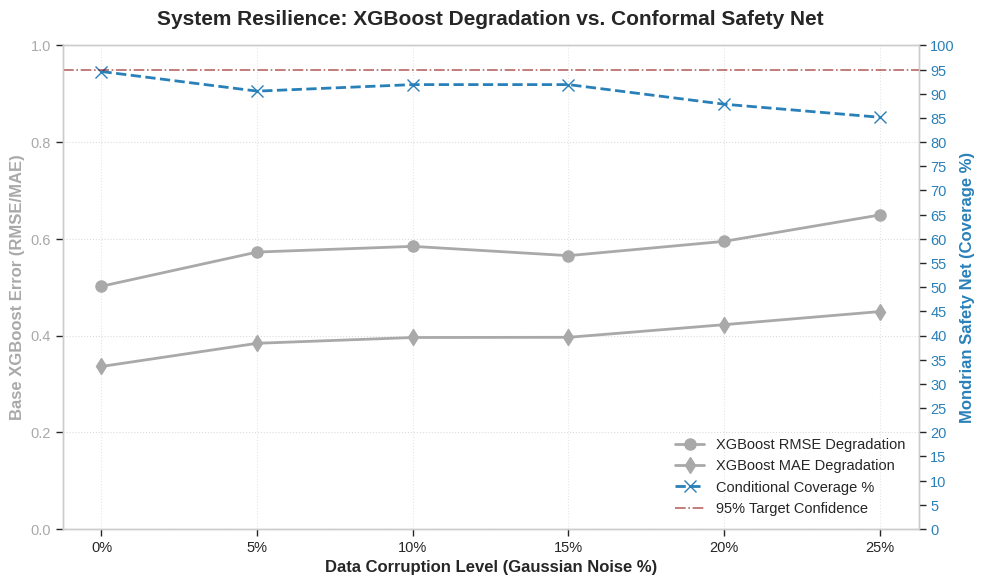

In [32]:
# ==============================================================
# CELL: EMPIRICAL ROBUSTNESS & GRACEFUL DEGRADATION TEST (LEAK-FREE)
# ==============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from IPython.display import display
np.random.seed(42)

print("==========================================================")
print("ADVERSARIAL ROBUSTNESS REPORT (TEST SET ONLY)")
print("==========================================================")

# 1. Isolate the Strictly Unseen Test Set (From the previous cell's split)
X_test_clean = X.loc[test_idx]
Y_test_clean = y.loc[test_idx]

# Re-establish test masks to ensure correct Mondrian bounds are applied
test_emerging_mask = X_test_clean[wealth_proxy] <= median_wealth
test_established_mask = X_test_clean[wealth_proxy] > median_wealth

# Baseline Performance (Uncorrupted Test Data)
clean_preds = champion_model.predict(X_test_clean)
baseline_rmse = np.sqrt(mean_squared_error(Y_test_clean, clean_preds))
baseline_mae = mean_absolute_error(Y_test_clean, clean_preds)

# 2. Define the Step-Wise Perturbation Matrix
noise_levels = [0.00, 0.05, 0.10, 0.15, 0.20, 0.25] # Added 25% for an extreme macroeconomic shock scenario
report_data = []
std_devs = X_test_clean.std(axis=0)

# 3. Execute the Degradation Loop
for noise in noise_levels:
    np.random.seed(42) # Ensure reproducible noise arrays

    # Generate and inject noise (Gaussian corruption)
    noise_matrix = np.random.normal(0, noise * std_devs, size=X_test_clean.shape)
    X_test_noisy = X_test_clean + noise_matrix

    # Predict on corrupted data
    noisy_preds = champion_model.predict(X_test_noisy)

    # Calculate Error Metrics
    noisy_rmse = np.sqrt(mean_squared_error(Y_test_clean, noisy_preds))
    noisy_mae = mean_absolute_error(Y_test_clean, noisy_preds)

    # Calculate Dynamic Mondrian Coverage on the noisy predictions
    lower_bound = np.where(test_emerging_mask, noisy_preds - q_emerging, noisy_preds - q_established)
    upper_bound = np.where(test_emerging_mask, noisy_preds + q_emerging, noisy_preds + q_established)
    coverage = np.mean((Y_test_clean >= lower_bound) & (Y_test_clean <= upper_bound)) * 100

    # Log Results
    report_data.append({
        'Corruption_Level': f"{int(noise*100)}%",
        'Noise_Std': noise,
        'XGBoost_RMSE': noisy_rmse,
        'XGBoost_MAE': noisy_mae,
        'Mondrian_Coverage_Pct': coverage
    })

# 4. Generate the Tabular Output
df_robustness = pd.DataFrame(report_data)
display(df_robustness.round(3))

# ==============================================================
# --- Step 2: Visualizing Graceful Degradation ---
# ==============================================================
print("\n--- Step 2: Visualizing Graceful Degradation ---")

fig, ax1 = plt.subplots(figsize=(10, 6))

# X-Axis Data
x_labels = df_robustness['Corruption_Level']
x_pos = np.arange(len(x_labels))

# Plot 1: Base Error (Left Y-Axis - Red Solid Line)
color1 = 'darkgrey'
ax1.set_xlabel('Data Corruption Level (Gaussian Noise %)', fontweight='bold', fontsize=12)
ax1.set_ylabel('Base XGBoost Error (RMSE/MAE)', color=color1, fontweight='bold', fontsize=12)
line1a = ax1.plot(x_pos, df_robustness['XGBoost_RMSE'], color=color1, marker='o',
                 markersize=8, linewidth=2, label='XGBoost RMSE Degradation')
line1b = ax1.plot(x_pos, df_robustness['XGBoost_MAE'], color=color1, marker='d',
                 markersize=8, linewidth=2, label='XGBoost MAE Degradation')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(x_labels)
ax1.grid(axis='y', linestyle=':', alpha=0.7)
ax1.grid(axis='x', linestyle=':', alpha=0.5)
ax1.set_ylim(0, 1)


# Plot 2: Conformal Coverage (Right Y-Axis - Blue Dashed Line)
ax2 = ax1.twinx()
color2 = '#2980b9'
ax2.set_ylabel('Mondrian Safety Net (Coverage %)', color=color2, fontweight='bold', fontsize=12)
line2 = ax2.plot(x_pos, df_robustness['Mondrian_Coverage_Pct'], color=color2, marker='x',
                 markersize=8, linestyle='--', linewidth=2, label='Conditional Coverage %')
ax2.tick_params(axis='y', labelcolor=color2)

# Set the right Y-axis limits strictly around the 95% mark to show stability clearly
ax2.set_ylim(0, 100)
plt.yticks(np.arange(0, 101, 5))

# Add the 95% target baseline
ax2.axhline(95.0, color='darkred', linestyle='-.', alpha=0.6, label='95% Target Confidence')

# Title and Layout
plt.title("System Resilience: XGBoost Degradation vs. Conformal Safety Net", fontsize=15, fontweight='bold', pad=15)

# Combine legends from both axes
lines = line1a + line1b + line2 + [ax2.lines[-1]]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='lower right', framealpha=0.7)

plt.grid(False)
plt.tight_layout()
plt.show()